In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
from pathlib import Path

# ---------------- CONFIG ----------------
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 42                          # 42 first, then change to 13 or 87 later

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
N_BINS = 15

# ---------------- PATHS ----------------
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

SOURCE_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
TARGET_RUN_DIR = CALIBRATION_DIR / RUN_NAME
TARGET_RUN_DIR.mkdir(parents=True, exist_ok=True)

VAL_PRED_CSV = SOURCE_RUN_DIR / "val_predictions.csv"
TEST_PRED_CSV = SOURCE_RUN_DIR / "test_predictions.csv"

print("BASE_DIR       :", BASE_DIR)
print("PROJECT_ROOT   :", PROJECT_ROOT)
print("SOURCE_RUN_DIR :", SOURCE_RUN_DIR)
print("TARGET_RUN_DIR :", TARGET_RUN_DIR)
print("VAL_PRED_CSV   :", VAL_PRED_CSV, "->", VAL_PRED_CSV.exists())
print("TEST_PRED_CSV  :", TEST_PRED_CSV, "->", TEST_PRED_CSV.exists())

BASE_DIR       : /mnt/e/CVPR
PROJECT_ROOT   : /mnt/e/CVPR/steel_failure_aware
SOURCE_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
TARGET_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
VAL_PRED_CSV   : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/val_predictions.csv -> True
TEST_PRED_CSV  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/test_predictions.csv -> True


In [3]:
val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

print("val_df shape :", val_df.shape)
print("test_df shape:", test_df.shape)

display(val_df.head(2))
display(test_df.head(2))

val_df shape : (347, 23)
test_df shape: (347, 23)


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/4/img_03_425003700_00402.jpg,3,3,0.029272,-0.822133,0.022927,-1.066434,0.039578,-0.520485,0.535229,...,0.063945,-0.040734,0.035255,-0.636152,0.110416,0.505499,0.133646,0.696433,0.015541,-1.455292
1,/mnt/e/CVPR/GC10/4/img_02_4403466200_00005.jpg,3,3,0.009602,-1.322223,0.028420,-0.237090,0.002322,-2.741936,0.764788,...,0.005915,-1.806759,0.015597,-0.837087,0.065565,0.598863,0.089803,0.913447,0.009217,-1.363073


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/1/img_06_3403403800_00910.jpg,0,0,0.956638,4.997797,0.004873,-0.281872,0.000520,-2.520230,0.000705,...,0.000208,-3.43760,0.005931,-0.085381,0.025349,1.367123,0.002907,-0.798505,0.001203,-1.680403
1,/mnt/e/CVPR/GC10/4/img_03_3402617800_00047.jpg,3,3,0.014579,-1.313959,0.008749,-1.824569,0.013724,-1.374405,0.521954,...,0.010031,-1.68788,0.008460,-1.858185,0.215955,1.381522,0.159996,1.081600,0.012389,-1.476753


In [4]:
logit_cols = [c for c in val_df.columns if c.startswith("logit_class_")]
prob_cols = [c for c in val_df.columns if c.startswith("prob_class_")]

if len(logit_cols) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} logit columns, found {len(logit_cols)}")

if len(prob_cols) != NUM_CLASSES:
    print("Warning: probability columns not found exactly as expected. Continuing with logits only.")

logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[-1]))
prob_cols = sorted(prob_cols, key=lambda x: int(x.split("_")[-1])) if len(prob_cols) == NUM_CLASSES else []

val_logits = val_df[logit_cols].values.astype(np.float32)
test_logits = test_df[logit_cols].values.astype(np.float32)

val_labels = val_df["y_true"].values.astype(np.int64)
test_labels = test_df["y_true"].values.astype(np.int64)

print("val_logits shape :", val_logits.shape)
print("test_logits shape:", test_logits.shape)
print("val_labels shape :", val_labels.shape)
print("test_labels shape:", test_labels.shape)

val_logits shape : (347, 10)
test_logits shape: (347, 10)
val_labels shape : (347,)
test_labels shape: (347,)


In [5]:
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data

In [6]:
def plot_reliability_diagram(bin_data, title, save_path=None):
    bin_centers = []
    bin_accs = []
    bin_confs = []
    widths = []

    for row in bin_data:
        center = (row["bin_lower"] + row["bin_upper"]) / 2.0
        width = row["bin_upper"] - row["bin_lower"]
        bin_centers.append(center)
        bin_accs.append(row["bin_acc"])
        bin_confs.append(row["bin_conf"])
        widths.append(width)

    plt.figure(figsize=(7, 6))
    plt.bar(bin_centers, bin_accs, width=widths, alpha=0.7, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [7]:
val_logits_t = torch.tensor(val_logits, dtype=torch.float32)
val_labels_t = torch.tensor(val_labels, dtype=torch.long)

log_temperature = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

optimizer = optim.LBFGS([log_temperature], lr=0.01, max_iter=100)

def closure():
    optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_logits = val_logits_t / temperature
    loss = nn.CrossEntropyLoss()(scaled_logits, val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)

best_temperature = float(torch.exp(log_temperature).item())

print("Learned temperature T:", best_temperature)

Learned temperature T: 0.8825289011001587


In [8]:
val_logits_cal = val_logits / best_temperature
test_logits_cal = test_logits / best_temperature

val_probs_uncal = softmax_numpy(val_logits)
test_probs_uncal = softmax_numpy(test_logits)

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

print("Validation and test calibrated probabilities computed.")

Validation and test calibrated probabilities computed.


In [9]:
# ---------- Validation ----------
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)

val_brier_uncal = multiclass_brier_score(val_probs_uncal, val_labels, NUM_CLASSES)
val_brier_cal = multiclass_brier_score(val_probs_cal, val_labels, NUM_CLASSES)

val_ece_uncal, val_mce_uncal, val_bins_uncal = ece_mce_from_probs(val_probs_uncal, val_labels, n_bins=N_BINS)
val_ece_cal, val_mce_cal, val_bins_cal = ece_mce_from_probs(val_probs_cal, val_labels, n_bins=N_BINS)

# ---------- Test ----------
test_nll_uncal = nll_from_logits(test_logits, test_labels)
test_nll_cal = nll_from_logits(test_logits_cal, test_labels)

test_brier_uncal = multiclass_brier_score(test_probs_uncal, test_labels, NUM_CLASSES)
test_brier_cal = multiclass_brier_score(test_probs_cal, test_labels, NUM_CLASSES)

test_ece_uncal, test_mce_uncal, test_bins_uncal = ece_mce_from_probs(test_probs_uncal, test_labels, n_bins=N_BINS)
test_ece_cal, test_mce_cal, test_bins_cal = ece_mce_from_probs(test_probs_cal, test_labels, n_bins=N_BINS)

metrics_rows = [
    {
        "split": "val",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": val_nll_uncal,
        "brier": val_brier_uncal,
        "ece": val_ece_uncal,
        "mce": val_mce_uncal,
    },
    {
        "split": "val",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": val_nll_cal,
        "brier": val_brier_cal,
        "ece": val_ece_cal,
        "mce": val_mce_cal,
    },
    {
        "split": "test",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": test_nll_uncal,
        "brier": test_brier_uncal,
        "ece": test_ece_uncal,
        "mce": test_mce_uncal,
    },
    {
        "split": "test",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": test_nll_cal,
        "brier": test_brier_cal,
        "ece": test_ece_cal,
        "mce": test_mce_cal,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

,split,setting,temperature,nll,brier,ece,mce
0,val,uncalibrated,1.000000,0.617443,0.282419,0.078246,0.808987
1,val,calibrated,0.882529,0.599231,0.276886,0.056828,0.798703
2,test,uncalibrated,1.000000,0.558671,0.243274,0.116475,0.261537
3,test,calibrated,0.882529,0.521033,0.230820,0.083966,0.241654


In [10]:
metrics_csv = TARGET_RUN_DIR / "calibration_metrics.csv"
metrics_json = TARGET_RUN_DIR / "calibration_metrics.json"
temperature_json = TARGET_RUN_DIR / "temperature.json"

metrics_df.to_csv(metrics_csv, index=False)

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

with open(temperature_json, "w", encoding="utf-8") as f:
    json.dump({"temperature": best_temperature}, f, indent=2)

print("Saved:", metrics_csv)
print("Saved:", metrics_json)
print("Saved:", temperature_json)

Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/calibration_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/calibration_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/temperature.json


In [11]:
val_cal_df = val_df.copy()
test_cal_df = test_df.copy()

for c in range(NUM_CLASSES):
    val_cal_df[f"cal_prob_class_{c}"] = val_probs_cal[:, c]
    val_cal_df[f"cal_logit_class_{c}"] = val_logits_cal[:, c]

    test_cal_df[f"cal_prob_class_{c}"] = test_probs_cal[:, c]
    test_cal_df[f"cal_logit_class_{c}"] = test_logits_cal[:, c]

val_cal_csv = TARGET_RUN_DIR / "val_predictions_calibrated.csv"
test_cal_csv = TARGET_RUN_DIR / "test_predictions_calibrated.csv"

val_cal_df.to_csv(val_cal_csv, index=False)
test_cal_df.to_csv(test_cal_csv, index=False)

print("Saved:", val_cal_csv)
print("Saved:", test_cal_csv)

Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/val_predictions_calibrated.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/test_predictions_calibrated.csv


In [12]:
val_bins_uncal_df = pd.DataFrame(val_bins_uncal)
val_bins_cal_df = pd.DataFrame(val_bins_cal)
test_bins_uncal_df = pd.DataFrame(test_bins_uncal)
test_bins_cal_df = pd.DataFrame(test_bins_cal)

val_bins_uncal_df.to_csv(TARGET_RUN_DIR / "val_bins_uncalibrated.csv", index=False)
val_bins_cal_df.to_csv(TARGET_RUN_DIR / "val_bins_calibrated.csv", index=False)
test_bins_uncal_df.to_csv(TARGET_RUN_DIR / "test_bins_uncalibrated.csv", index=False)
test_bins_cal_df.to_csv(TARGET_RUN_DIR / "test_bins_calibrated.csv", index=False)

print("Saved all bin tables.")

Saved all bin tables.


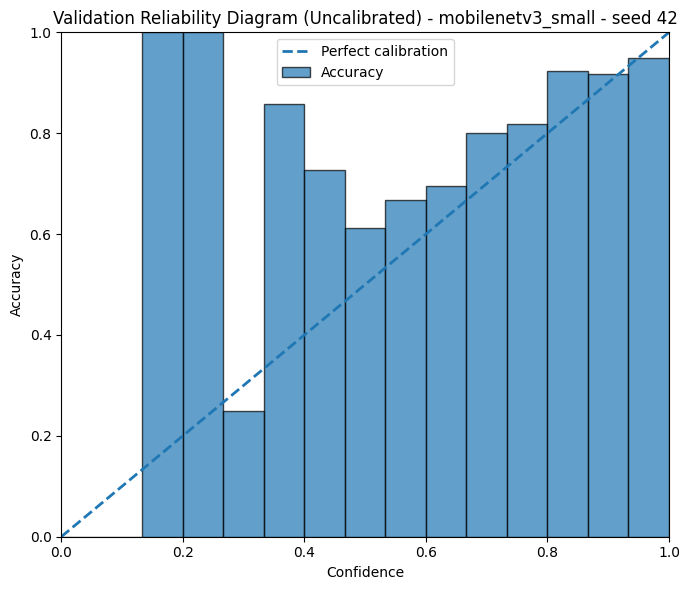

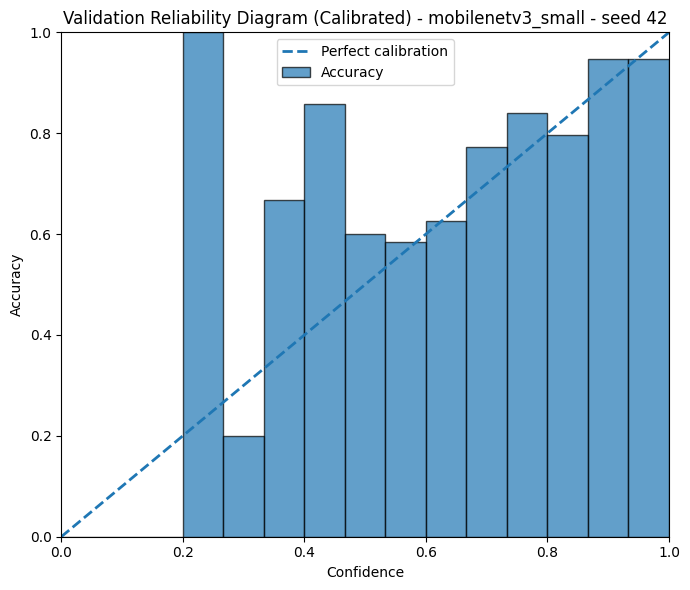

In [13]:
plot_reliability_diagram(
    val_bins_uncal,
    title=f"Validation Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    val_bins_cal,
    title=f"Validation Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_calibrated.png"
)

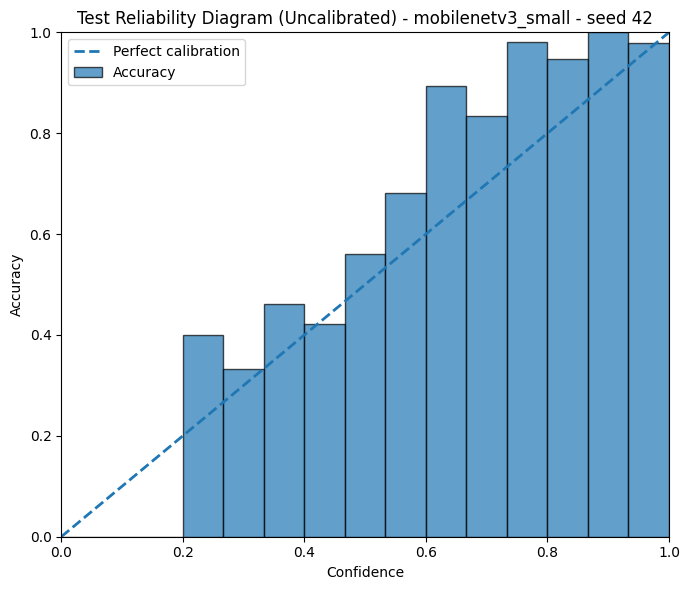

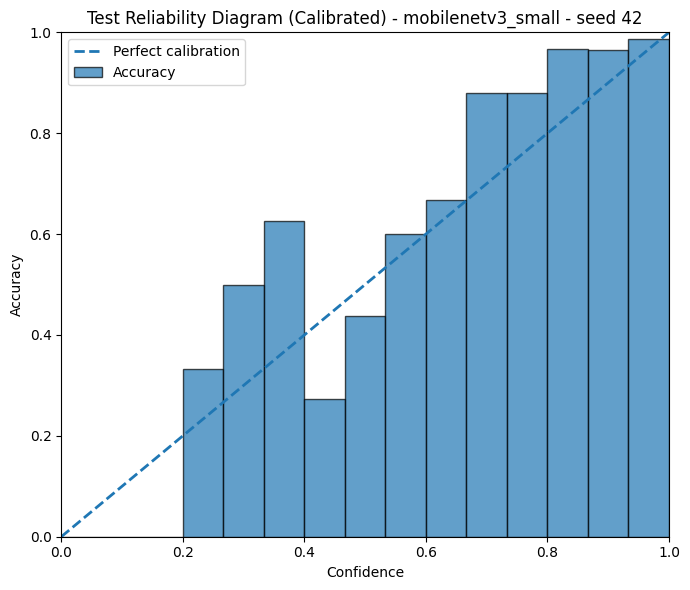

In [14]:
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)

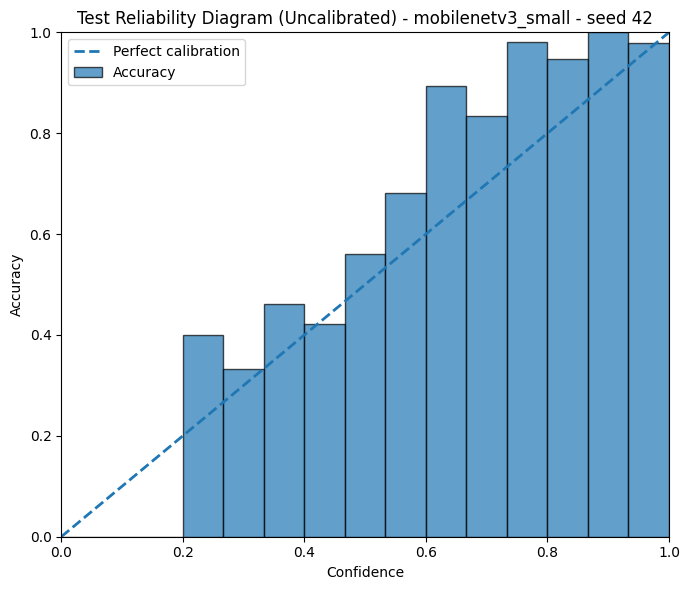

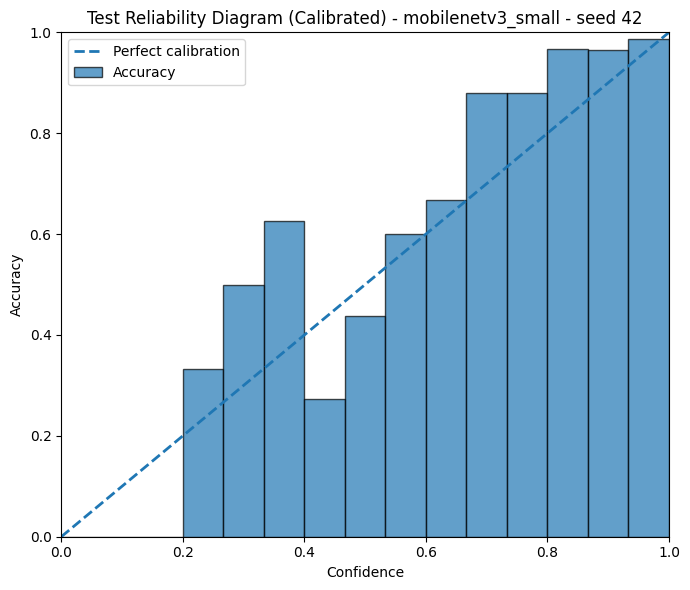

In [15]:
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)

In [16]:
print("\nMODEL:", MODEL_NAME)
print("SEED :", SEED)
print("TEMPERATURE:", round(best_temperature, 6))

print("\nValidation metrics")
print(metrics_df[metrics_df["split"] == "val"].to_string(index=False))

print("\nTest metrics")
print(metrics_df[metrics_df["split"] == "test"].to_string(index=False))


MODEL: mobilenetv3_small
SEED : 42
TEMPERATURE: 0.882529

Validation metrics
split      setting  temperature      nll    brier      ece      mce
  val uncalibrated     1.000000 0.617443 0.282419 0.078246 0.808987
  val   calibrated     0.882529 0.599231 0.276886 0.056828 0.798703

Test metrics
split      setting  temperature      nll    brier      ece      mce
 test uncalibrated     1.000000 0.558671 0.243274 0.116475 0.261537
 test   calibrated     0.882529 0.521033 0.230820 0.083966 0.241654


In [17]:
saved_files = sorted([p.name for p in TARGET_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)

Saved files:
- calibration_metrics.csv
- calibration_metrics.json
- temperature.json
- test_bins_calibrated.csv
- test_bins_uncalibrated.csv
- test_predictions_calibrated.csv
- test_reliability_calibrated.png
- test_reliability_uncalibrated.png
- val_bins_calibrated.csv
- val_bins_uncalibrated.csv
- val_predictions_calibrated.csv
- val_reliability_calibrated.png
- val_reliability_uncalibrated.png


Imports loaded successfully.
BASE_DIR       : /mnt/e/CVPR
PROJECT_ROOT   : /mnt/e/CVPR/steel_failure_aware
SOURCE_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
TARGET_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
VAL_PRED_CSV   : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_predictions.csv -> True
TEST_PRED_CSV  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_predictions.csv -> True
val_df shape : (347, 23)
test_df shape: (347, 23)


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/8/img_02_425392400_00020.jpg,7,6,0.021323,-0.914202,0.056890,0.067142,0.025486,-0.735839,0.083145,...,0.019845,-0.986006,0.470279,2.179357,0.075003,0.343556,0.024941,-0.757449,0.154417,1.065690
1,/mnt/e/CVPR/GC10/4/img_03_424992500_00514.jpg,3,3,0.001022,-1.342468,0.000718,-1.695311,0.000777,-1.615830,0.956491,...,0.001657,-0.859131,0.006709,0.539497,0.005648,0.367442,0.024956,1.853211,0.000903,-1.466036


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/4/img_01_425241400_00053.jpg,3,3,0.002388,-1.343494,0.000786,-2.454539,0.003221,-1.044395,0.892458,...,0.012104,0.279364,0.010952,0.179395,0.044059,1.571392,0.024578,0.987693,0.003669,-0.914221
1,/mnt/e/CVPR/GC10/2/img_02_425505700_00018.jpg,1,1,0.091972,1.638148,0.793886,3.793607,0.003238,-1.708235,0.000745,...,0.000509,-3.557980,0.005270,-1.221367,0.066763,1.317815,0.008457,-0.748304,0.019429,0.083427


val_logits shape : (347, 10)
test_logits shape: (347, 10)
val_labels shape : (347,)
test_labels shape: (347,)
Learned temperature T: 0.8548519015312195
Validation and test calibrated probabilities computed.


,split,setting,temperature,nll,brier,ece,mce
0,val,uncalibrated,1.000000,0.552178,0.243456,0.087534,0.252104
1,val,calibrated,0.854852,0.524520,0.234185,0.074043,0.232604
2,test,uncalibrated,1.000000,0.463741,0.197616,0.115854,0.404556
3,test,calibrated,0.854852,0.424178,0.186479,0.058320,0.371561


Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/calibration_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/calibration_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/temperature.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_predictions_calibrated.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_predictions_calibrated.csv
Saved all bin tables.


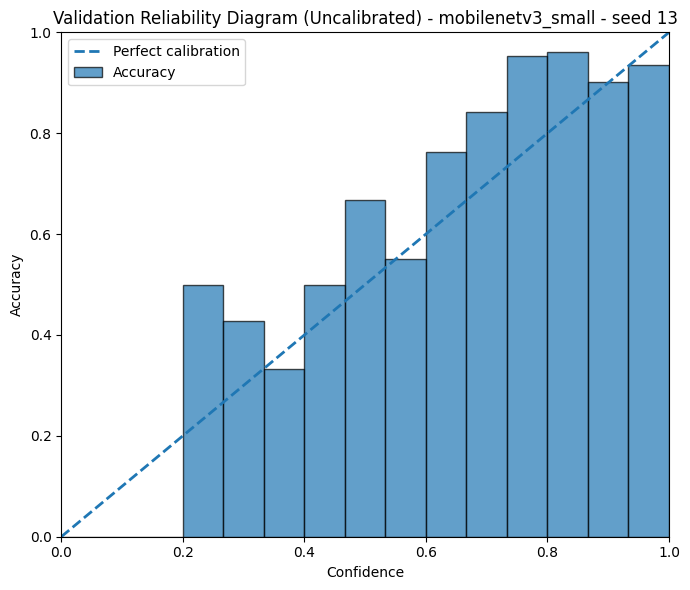

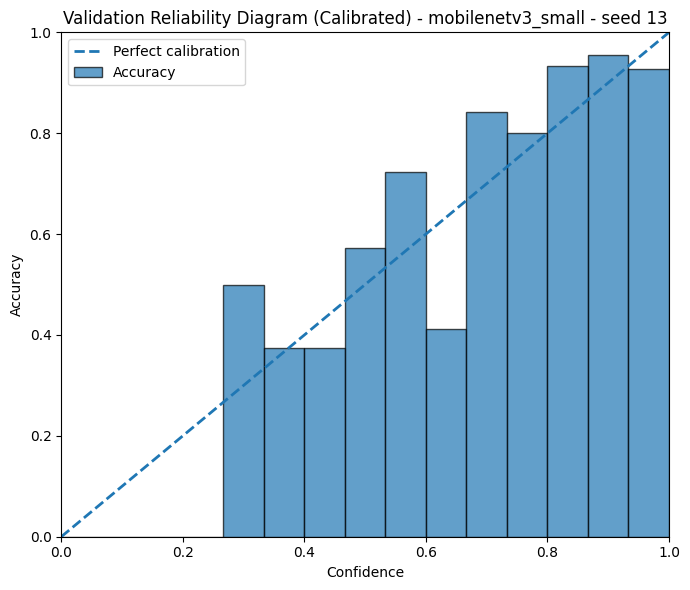

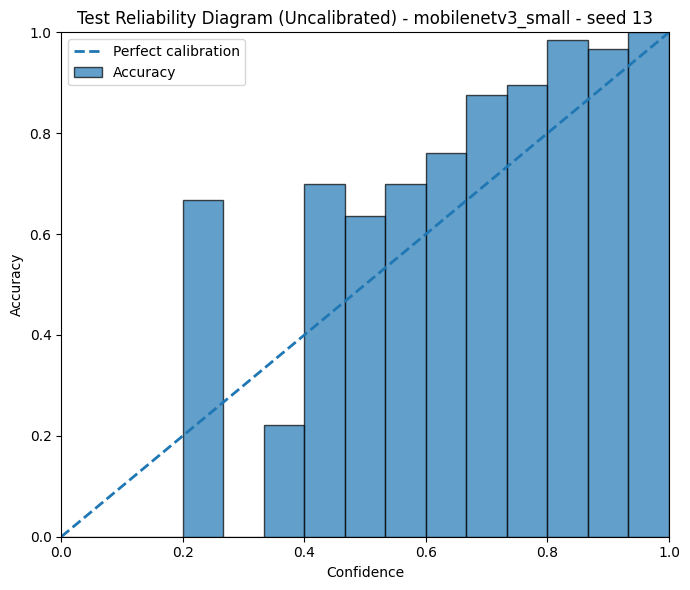

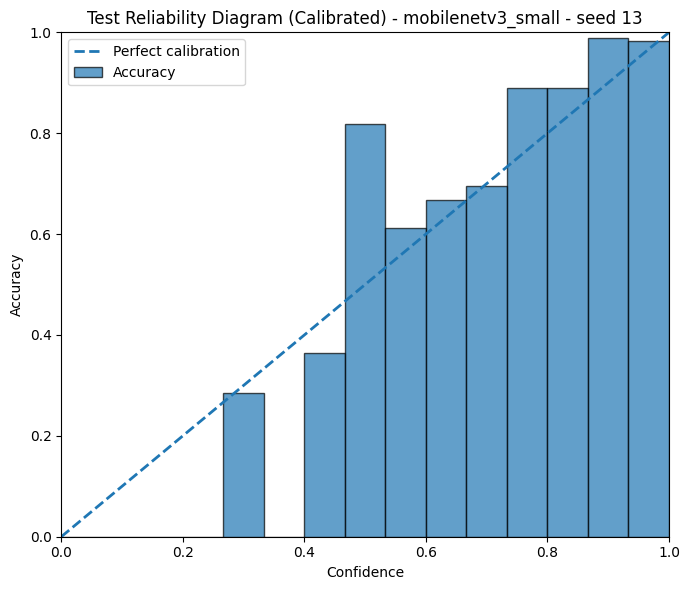


MODEL: mobilenetv3_small
SEED : 13
TEMPERATURE: 0.854852

Validation metrics
split      setting  temperature      nll    brier      ece      mce
  val uncalibrated     1.000000 0.552178 0.243456 0.087534 0.252104
  val   calibrated     0.854852 0.524520 0.234185 0.074043 0.232604

Test metrics
split      setting  temperature      nll    brier      ece      mce
 test uncalibrated     1.000000 0.463741 0.197616 0.115854 0.404556
 test   calibrated     0.854852 0.424178 0.186479 0.058320 0.371561
Saved files:
- calibration_metrics.csv
- calibration_metrics.json
- temperature.json
- test_bins_calibrated.csv
- test_bins_uncalibrated.csv
- test_predictions_calibrated.csv
- test_reliability_calibrated.png
- test_reliability_uncalibrated.png
- val_bins_calibrated.csv
- val_bins_uncalibrated.csv
- val_predictions_calibrated.csv
- val_reliability_calibrated.png
- val_reliability_uncalibrated.png


In [18]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# ---------------- CONFIG ----------------
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 13                          # 42 first, then change to 13 or 87 later

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
N_BINS = 15

# ---------------- PATHS ----------------
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

SOURCE_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
TARGET_RUN_DIR = CALIBRATION_DIR / RUN_NAME
TARGET_RUN_DIR.mkdir(parents=True, exist_ok=True)

VAL_PRED_CSV = SOURCE_RUN_DIR / "val_predictions.csv"
TEST_PRED_CSV = SOURCE_RUN_DIR / "test_predictions.csv"

print("BASE_DIR       :", BASE_DIR)
print("PROJECT_ROOT   :", PROJECT_ROOT)
print("SOURCE_RUN_DIR :", SOURCE_RUN_DIR)
print("TARGET_RUN_DIR :", TARGET_RUN_DIR)
print("VAL_PRED_CSV   :", VAL_PRED_CSV, "->", VAL_PRED_CSV.exists())
print("TEST_PRED_CSV  :", TEST_PRED_CSV, "->", TEST_PRED_CSV.exists())
val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

print("val_df shape :", val_df.shape)
print("test_df shape:", test_df.shape)

display(val_df.head(2))
display(test_df.head(2))
logit_cols = [c for c in val_df.columns if c.startswith("logit_class_")]
prob_cols = [c for c in val_df.columns if c.startswith("prob_class_")]

if len(logit_cols) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} logit columns, found {len(logit_cols)}")

if len(prob_cols) != NUM_CLASSES:
    print("Warning: probability columns not found exactly as expected. Continuing with logits only.")

logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[-1]))
prob_cols = sorted(prob_cols, key=lambda x: int(x.split("_")[-1])) if len(prob_cols) == NUM_CLASSES else []

val_logits = val_df[logit_cols].values.astype(np.float32)
test_logits = test_df[logit_cols].values.astype(np.float32)

val_labels = val_df["y_true"].values.astype(np.int64)
test_labels = test_df["y_true"].values.astype(np.int64)

print("val_logits shape :", val_logits.shape)
print("test_logits shape:", test_logits.shape)
print("val_labels shape :", val_labels.shape)
print("test_labels shape:", test_labels.shape)
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def plot_reliability_diagram(bin_data, title, save_path=None):
    bin_centers = []
    bin_accs = []
    bin_confs = []
    widths = []

    for row in bin_data:
        center = (row["bin_lower"] + row["bin_upper"]) / 2.0
        width = row["bin_upper"] - row["bin_lower"]
        bin_centers.append(center)
        bin_accs.append(row["bin_acc"])
        bin_confs.append(row["bin_conf"])
        widths.append(width)

    plt.figure(figsize=(7, 6))
    plt.bar(bin_centers, bin_accs, width=widths, alpha=0.7, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
val_logits_t = torch.tensor(val_logits, dtype=torch.float32)
val_labels_t = torch.tensor(val_labels, dtype=torch.long)

log_temperature = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

optimizer = optim.LBFGS([log_temperature], lr=0.01, max_iter=100)

def closure():
    optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_logits = val_logits_t / temperature
    loss = nn.CrossEntropyLoss()(scaled_logits, val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)

best_temperature = float(torch.exp(log_temperature).item())

print("Learned temperature T:", best_temperature)
val_logits_cal = val_logits / best_temperature
test_logits_cal = test_logits / best_temperature

val_probs_uncal = softmax_numpy(val_logits)
test_probs_uncal = softmax_numpy(test_logits)

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

print("Validation and test calibrated probabilities computed.")
# ---------- Validation ----------
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)

val_brier_uncal = multiclass_brier_score(val_probs_uncal, val_labels, NUM_CLASSES)
val_brier_cal = multiclass_brier_score(val_probs_cal, val_labels, NUM_CLASSES)

val_ece_uncal, val_mce_uncal, val_bins_uncal = ece_mce_from_probs(val_probs_uncal, val_labels, n_bins=N_BINS)
val_ece_cal, val_mce_cal, val_bins_cal = ece_mce_from_probs(val_probs_cal, val_labels, n_bins=N_BINS)

# ---------- Test ----------
test_nll_uncal = nll_from_logits(test_logits, test_labels)
test_nll_cal = nll_from_logits(test_logits_cal, test_labels)

test_brier_uncal = multiclass_brier_score(test_probs_uncal, test_labels, NUM_CLASSES)
test_brier_cal = multiclass_brier_score(test_probs_cal, test_labels, NUM_CLASSES)

test_ece_uncal, test_mce_uncal, test_bins_uncal = ece_mce_from_probs(test_probs_uncal, test_labels, n_bins=N_BINS)
test_ece_cal, test_mce_cal, test_bins_cal = ece_mce_from_probs(test_probs_cal, test_labels, n_bins=N_BINS)

metrics_rows = [
    {
        "split": "val",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": val_nll_uncal,
        "brier": val_brier_uncal,
        "ece": val_ece_uncal,
        "mce": val_mce_uncal,
    },
    {
        "split": "val",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": val_nll_cal,
        "brier": val_brier_cal,
        "ece": val_ece_cal,
        "mce": val_mce_cal,
    },
    {
        "split": "test",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": test_nll_uncal,
        "brier": test_brier_uncal,
        "ece": test_ece_uncal,
        "mce": test_mce_uncal,
    },
    {
        "split": "test",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": test_nll_cal,
        "brier": test_brier_cal,
        "ece": test_ece_cal,
        "mce": test_mce_cal,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
metrics_csv = TARGET_RUN_DIR / "calibration_metrics.csv"
metrics_json = TARGET_RUN_DIR / "calibration_metrics.json"
temperature_json = TARGET_RUN_DIR / "temperature.json"

metrics_df.to_csv(metrics_csv, index=False)

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

with open(temperature_json, "w", encoding="utf-8") as f:
    json.dump({"temperature": best_temperature}, f, indent=2)

print("Saved:", metrics_csv)
print("Saved:", metrics_json)
print("Saved:", temperature_json)
val_cal_df = val_df.copy()
test_cal_df = test_df.copy()

for c in range(NUM_CLASSES):
    val_cal_df[f"cal_prob_class_{c}"] = val_probs_cal[:, c]
    val_cal_df[f"cal_logit_class_{c}"] = val_logits_cal[:, c]

    test_cal_df[f"cal_prob_class_{c}"] = test_probs_cal[:, c]
    test_cal_df[f"cal_logit_class_{c}"] = test_logits_cal[:, c]

val_cal_csv = TARGET_RUN_DIR / "val_predictions_calibrated.csv"
test_cal_csv = TARGET_RUN_DIR / "test_predictions_calibrated.csv"

val_cal_df.to_csv(val_cal_csv, index=False)
test_cal_df.to_csv(test_cal_csv, index=False)

print("Saved:", val_cal_csv)
print("Saved:", test_cal_csv)
val_bins_uncal_df = pd.DataFrame(val_bins_uncal)
val_bins_cal_df = pd.DataFrame(val_bins_cal)
test_bins_uncal_df = pd.DataFrame(test_bins_uncal)
test_bins_cal_df = pd.DataFrame(test_bins_cal)

val_bins_uncal_df.to_csv(TARGET_RUN_DIR / "val_bins_uncalibrated.csv", index=False)
val_bins_cal_df.to_csv(TARGET_RUN_DIR / "val_bins_calibrated.csv", index=False)
test_bins_uncal_df.to_csv(TARGET_RUN_DIR / "test_bins_uncalibrated.csv", index=False)
test_bins_cal_df.to_csv(TARGET_RUN_DIR / "test_bins_calibrated.csv", index=False)

print("Saved all bin tables.")
plot_reliability_diagram(
    val_bins_uncal,
    title=f"Validation Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    val_bins_cal,
    title=f"Validation Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_calibrated.png"
)
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)
print("\nMODEL:", MODEL_NAME)
print("SEED :", SEED)
print("TEMPERATURE:", round(best_temperature, 6))

print("\nValidation metrics")
print(metrics_df[metrics_df["split"] == "val"].to_string(index=False))

print("\nTest metrics")
print(metrics_df[metrics_df["split"] == "test"].to_string(index=False))
saved_files = sorted([p.name for p in TARGET_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)



Imports loaded successfully.
BASE_DIR       : /mnt/e/CVPR
PROJECT_ROOT   : /mnt/e/CVPR/steel_failure_aware
SOURCE_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
TARGET_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
VAL_PRED_CSV   : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/val_predictions.csv -> True
TEST_PRED_CSV  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/test_predictions.csv -> True
val_df shape : (347, 23)
test_df shape: (347, 23)


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/3/img_08_425008500_00873.jpg,2,2,0.008305,-1.065879,0.003955,-1.807881,0.707486,3.378936,0.003218,...,0.011457,-0.744178,0.169685,1.951164,0.043343,0.586358,0.01752,-0.319453,0.008022,-1.100649
1,/mnt/e/CVPR/GC10/6/img_02_436152900_00563.jpg,5,5,0.007692,-1.429168,0.005054,-1.849042,0.006179,-1.648067,0.045163,...,0.658247,3.020280,0.152922,1.560625,0.066117,0.722121,0.03864,0.184997,0.011837,-0.998084


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/9/img_01_4402117100_00006.jpg,8,7,0.005715,-2.577440,0.002077,-3.589690,0.010265,-1.991704,0.044726,...,0.033777,-0.800691,0.202233,0.988951,0.406954,1.688230,0.047103,-0.468139,0.172095,0.827574
1,/mnt/e/CVPR/GC10/3/img_08_425503800_00053.jpg,2,2,0.005951,-0.930967,0.025474,0.523174,0.900638,4.088620,0.002352,...,0.004876,-1.130226,0.009952,-0.416701,0.022087,0.380497,0.005569,-0.997305,0.017902,0.170431


val_logits shape : (347, 10)
test_logits shape: (347, 10)
val_labels shape : (347,)
test_labels shape: (347,)
Learned temperature T: 0.8230337500572205
Validation and test calibrated probabilities computed.


,split,setting,temperature,nll,brier,ece,mce
0,val,uncalibrated,1.000000,0.521429,0.226076,0.123952,0.446019
1,val,calibrated,0.823034,0.480120,0.211652,0.074109,0.303335
2,test,uncalibrated,1.000000,0.579798,0.247845,0.109546,0.303683
3,test,calibrated,0.823034,0.546039,0.233032,0.064090,0.144753


Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/calibration_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/calibration_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/temperature.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/val_predictions_calibrated.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/test_predictions_calibrated.csv
Saved all bin tables.


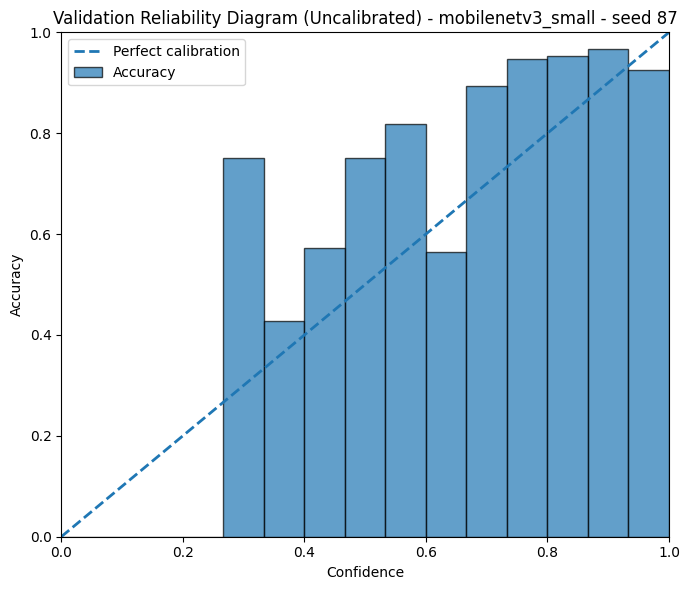

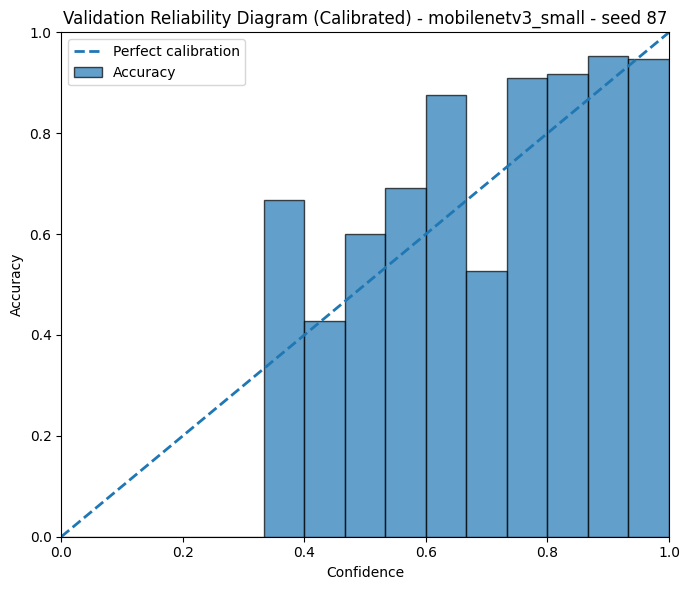

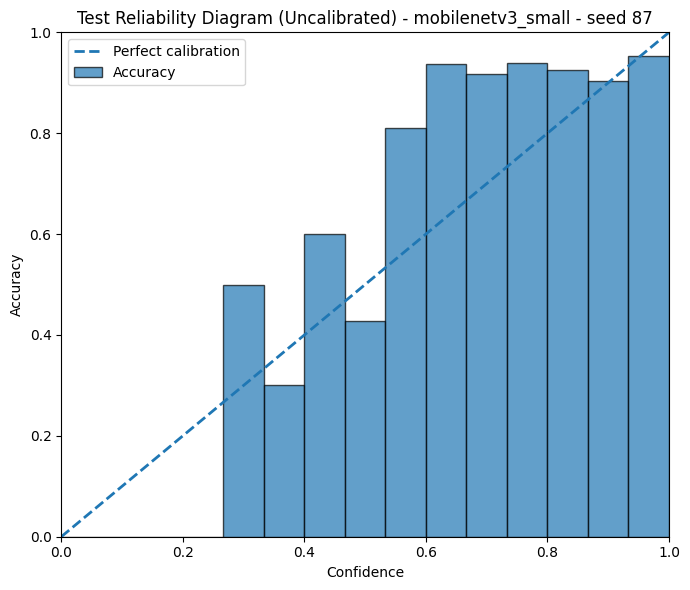

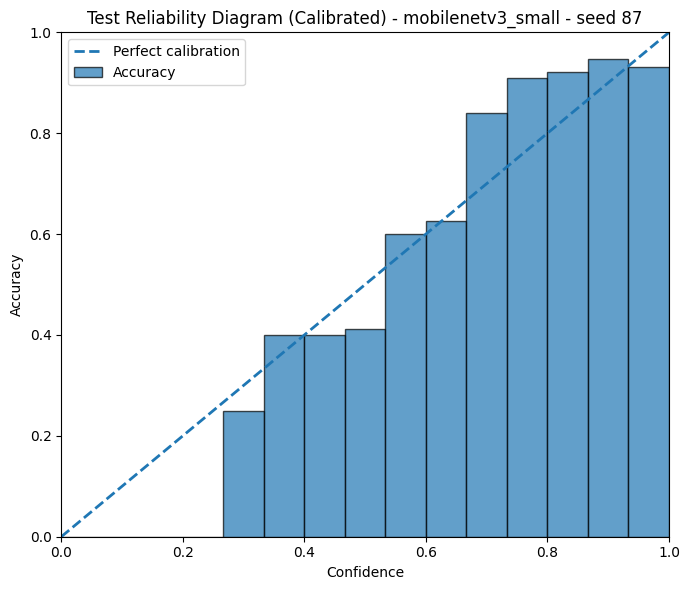


MODEL: mobilenetv3_small
SEED : 87
TEMPERATURE: 0.823034

Validation metrics
split      setting  temperature      nll    brier      ece      mce
  val uncalibrated     1.000000 0.521429 0.226076 0.123952 0.446019
  val   calibrated     0.823034 0.480120 0.211652 0.074109 0.303335

Test metrics
split      setting  temperature      nll    brier      ece      mce
 test uncalibrated     1.000000 0.579798 0.247845 0.109546 0.303683
 test   calibrated     0.823034 0.546039 0.233032 0.064090 0.144753
Saved files:
- calibration_metrics.csv
- calibration_metrics.json
- temperature.json
- test_bins_calibrated.csv
- test_bins_uncalibrated.csv
- test_predictions_calibrated.csv
- test_reliability_calibrated.png
- test_reliability_uncalibrated.png
- val_bins_calibrated.csv
- val_bins_uncalibrated.csv
- val_predictions_calibrated.csv
- val_reliability_calibrated.png
- val_reliability_uncalibrated.png


In [19]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# ---------------- CONFIG ----------------
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 87                          # 42 first, then change to 13 or 87 later

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
N_BINS = 15

# ---------------- PATHS ----------------
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

SOURCE_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
TARGET_RUN_DIR = CALIBRATION_DIR / RUN_NAME
TARGET_RUN_DIR.mkdir(parents=True, exist_ok=True)

VAL_PRED_CSV = SOURCE_RUN_DIR / "val_predictions.csv"
TEST_PRED_CSV = SOURCE_RUN_DIR / "test_predictions.csv"

print("BASE_DIR       :", BASE_DIR)
print("PROJECT_ROOT   :", PROJECT_ROOT)
print("SOURCE_RUN_DIR :", SOURCE_RUN_DIR)
print("TARGET_RUN_DIR :", TARGET_RUN_DIR)
print("VAL_PRED_CSV   :", VAL_PRED_CSV, "->", VAL_PRED_CSV.exists())
print("TEST_PRED_CSV  :", TEST_PRED_CSV, "->", TEST_PRED_CSV.exists())
val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

print("val_df shape :", val_df.shape)
print("test_df shape:", test_df.shape)

display(val_df.head(2))
display(test_df.head(2))
logit_cols = [c for c in val_df.columns if c.startswith("logit_class_")]
prob_cols = [c for c in val_df.columns if c.startswith("prob_class_")]

if len(logit_cols) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} logit columns, found {len(logit_cols)}")

if len(prob_cols) != NUM_CLASSES:
    print("Warning: probability columns not found exactly as expected. Continuing with logits only.")

logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[-1]))
prob_cols = sorted(prob_cols, key=lambda x: int(x.split("_")[-1])) if len(prob_cols) == NUM_CLASSES else []

val_logits = val_df[logit_cols].values.astype(np.float32)
test_logits = test_df[logit_cols].values.astype(np.float32)

val_labels = val_df["y_true"].values.astype(np.int64)
test_labels = test_df["y_true"].values.astype(np.int64)

print("val_logits shape :", val_logits.shape)
print("test_logits shape:", test_logits.shape)
print("val_labels shape :", val_labels.shape)
print("test_labels shape:", test_labels.shape)
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def plot_reliability_diagram(bin_data, title, save_path=None):
    bin_centers = []
    bin_accs = []
    bin_confs = []
    widths = []

    for row in bin_data:
        center = (row["bin_lower"] + row["bin_upper"]) / 2.0
        width = row["bin_upper"] - row["bin_lower"]
        bin_centers.append(center)
        bin_accs.append(row["bin_acc"])
        bin_confs.append(row["bin_conf"])
        widths.append(width)

    plt.figure(figsize=(7, 6))
    plt.bar(bin_centers, bin_accs, width=widths, alpha=0.7, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
val_logits_t = torch.tensor(val_logits, dtype=torch.float32)
val_labels_t = torch.tensor(val_labels, dtype=torch.long)

log_temperature = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

optimizer = optim.LBFGS([log_temperature], lr=0.01, max_iter=100)

def closure():
    optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_logits = val_logits_t / temperature
    loss = nn.CrossEntropyLoss()(scaled_logits, val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)

best_temperature = float(torch.exp(log_temperature).item())

print("Learned temperature T:", best_temperature)
val_logits_cal = val_logits / best_temperature
test_logits_cal = test_logits / best_temperature

val_probs_uncal = softmax_numpy(val_logits)
test_probs_uncal = softmax_numpy(test_logits)

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

print("Validation and test calibrated probabilities computed.")
# ---------- Validation ----------
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)

val_brier_uncal = multiclass_brier_score(val_probs_uncal, val_labels, NUM_CLASSES)
val_brier_cal = multiclass_brier_score(val_probs_cal, val_labels, NUM_CLASSES)

val_ece_uncal, val_mce_uncal, val_bins_uncal = ece_mce_from_probs(val_probs_uncal, val_labels, n_bins=N_BINS)
val_ece_cal, val_mce_cal, val_bins_cal = ece_mce_from_probs(val_probs_cal, val_labels, n_bins=N_BINS)

# ---------- Test ----------
test_nll_uncal = nll_from_logits(test_logits, test_labels)
test_nll_cal = nll_from_logits(test_logits_cal, test_labels)

test_brier_uncal = multiclass_brier_score(test_probs_uncal, test_labels, NUM_CLASSES)
test_brier_cal = multiclass_brier_score(test_probs_cal, test_labels, NUM_CLASSES)

test_ece_uncal, test_mce_uncal, test_bins_uncal = ece_mce_from_probs(test_probs_uncal, test_labels, n_bins=N_BINS)
test_ece_cal, test_mce_cal, test_bins_cal = ece_mce_from_probs(test_probs_cal, test_labels, n_bins=N_BINS)

metrics_rows = [
    {
        "split": "val",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": val_nll_uncal,
        "brier": val_brier_uncal,
        "ece": val_ece_uncal,
        "mce": val_mce_uncal,
    },
    {
        "split": "val",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": val_nll_cal,
        "brier": val_brier_cal,
        "ece": val_ece_cal,
        "mce": val_mce_cal,
    },
    {
        "split": "test",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": test_nll_uncal,
        "brier": test_brier_uncal,
        "ece": test_ece_uncal,
        "mce": test_mce_uncal,
    },
    {
        "split": "test",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": test_nll_cal,
        "brier": test_brier_cal,
        "ece": test_ece_cal,
        "mce": test_mce_cal,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
metrics_csv = TARGET_RUN_DIR / "calibration_metrics.csv"
metrics_json = TARGET_RUN_DIR / "calibration_metrics.json"
temperature_json = TARGET_RUN_DIR / "temperature.json"

metrics_df.to_csv(metrics_csv, index=False)

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

with open(temperature_json, "w", encoding="utf-8") as f:
    json.dump({"temperature": best_temperature}, f, indent=2)

print("Saved:", metrics_csv)
print("Saved:", metrics_json)
print("Saved:", temperature_json)
val_cal_df = val_df.copy()
test_cal_df = test_df.copy()

for c in range(NUM_CLASSES):
    val_cal_df[f"cal_prob_class_{c}"] = val_probs_cal[:, c]
    val_cal_df[f"cal_logit_class_{c}"] = val_logits_cal[:, c]

    test_cal_df[f"cal_prob_class_{c}"] = test_probs_cal[:, c]
    test_cal_df[f"cal_logit_class_{c}"] = test_logits_cal[:, c]

val_cal_csv = TARGET_RUN_DIR / "val_predictions_calibrated.csv"
test_cal_csv = TARGET_RUN_DIR / "test_predictions_calibrated.csv"

val_cal_df.to_csv(val_cal_csv, index=False)
test_cal_df.to_csv(test_cal_csv, index=False)

print("Saved:", val_cal_csv)
print("Saved:", test_cal_csv)
val_bins_uncal_df = pd.DataFrame(val_bins_uncal)
val_bins_cal_df = pd.DataFrame(val_bins_cal)
test_bins_uncal_df = pd.DataFrame(test_bins_uncal)
test_bins_cal_df = pd.DataFrame(test_bins_cal)

val_bins_uncal_df.to_csv(TARGET_RUN_DIR / "val_bins_uncalibrated.csv", index=False)
val_bins_cal_df.to_csv(TARGET_RUN_DIR / "val_bins_calibrated.csv", index=False)
test_bins_uncal_df.to_csv(TARGET_RUN_DIR / "test_bins_uncalibrated.csv", index=False)
test_bins_cal_df.to_csv(TARGET_RUN_DIR / "test_bins_calibrated.csv", index=False)

print("Saved all bin tables.")
plot_reliability_diagram(
    val_bins_uncal,
    title=f"Validation Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    val_bins_cal,
    title=f"Validation Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_calibrated.png"
)
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)
print("\nMODEL:", MODEL_NAME)
print("SEED :", SEED)
print("TEMPERATURE:", round(best_temperature, 6))

print("\nValidation metrics")
print(metrics_df[metrics_df["split"] == "val"].to_string(index=False))

print("\nTest metrics")
print(metrics_df[metrics_df["split"] == "test"].to_string(index=False))
saved_files = sorted([p.name for p in TARGET_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)



Imports loaded successfully.
BASE_DIR       : /mnt/e/CVPR
PROJECT_ROOT   : /mnt/e/CVPR/steel_failure_aware
SOURCE_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
TARGET_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
VAL_PRED_CSV   : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/val_predictions.csv -> True
TEST_PRED_CSV  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/test_predictions.csv -> True
val_df shape : (347, 23)
test_df shape: (347, 23)


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/4/img_03_425003700_00402.jpg,3,3,0.002249,-3.164512,0.041571,-0.247679,0.018604,-1.051706,0.462127,...,0.024207,-0.788444,0.170939,1.166237,0.155855,1.073857,0.112756,0.750158,0.007076,-2.018396
1,/mnt/e/CVPR/GC10/4/img_02_4403466200_00005.jpg,3,8,0.026696,-0.937728,0.064029,-0.062903,0.012020,-1.735644,0.032366,...,0.005396,-2.536638,0.167599,0.899343,0.310166,1.514875,0.312113,1.521133,0.025844,-0.970137


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/1/img_06_3403403800_00910.jpg,0,0,0.298935,1.273842,0.031619,-0.972631,0.017269,-1.577464,0.018281,...,0.011501,-1.983960,0.161322,0.657016,0.223177,0.981578,0.121127,0.370453,0.025385,-1.192213
1,/mnt/e/CVPR/GC10/4/img_03_3402617800_00047.jpg,3,3,0.017729,-0.784559,0.011307,-1.234294,0.018499,-0.742065,0.768275,...,0.007314,-1.669917,0.006630,-1.768163,0.088526,0.823535,0.033483,-0.148705,0.014542,-0.982738


val_logits shape : (347, 10)
test_logits shape: (347, 10)
val_labels shape : (347,)
test_labels shape: (347,)
Learned temperature T: 0.8821859359741211
Validation and test calibrated probabilities computed.


,split,setting,temperature,nll,brier,ece,mce
0,val,uncalibrated,1.000000,0.975303,0.427665,0.116639,0.345204
1,val,calibrated,0.882186,0.957580,0.417282,0.085984,0.271326
2,test,uncalibrated,1.000000,0.952841,0.415198,0.124220,0.293341
3,test,calibrated,0.882186,0.933131,0.403155,0.092393,0.260992


Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/calibration_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/calibration_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/temperature.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/val_predictions_calibrated.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/test_predictions_calibrated.csv
Saved all bin tables.


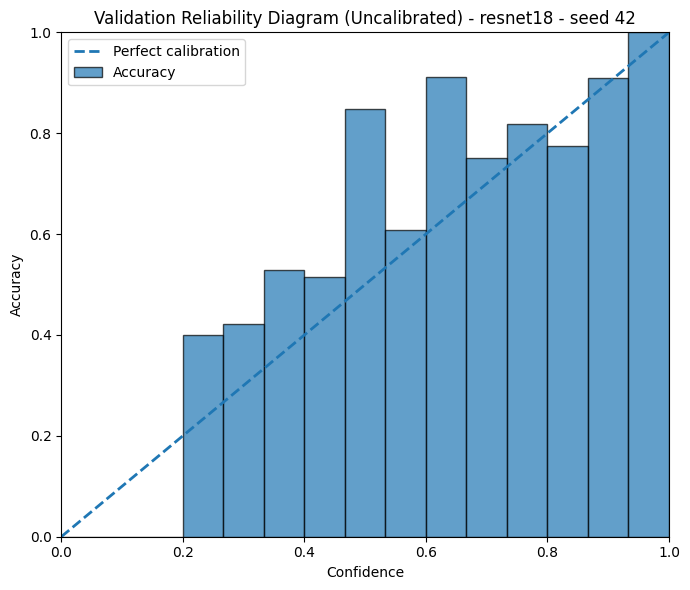

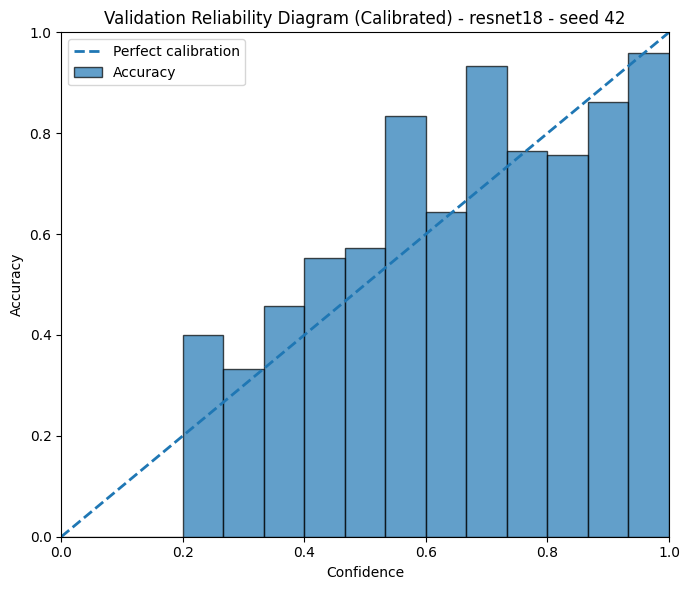

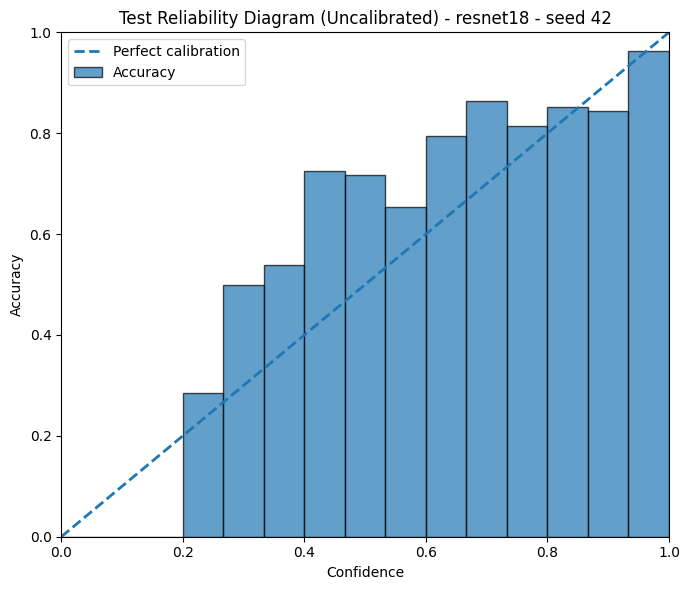

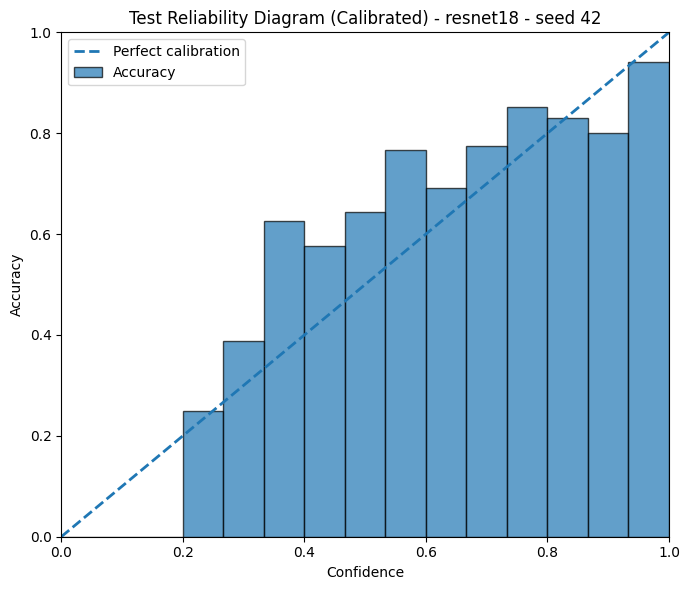


MODEL: resnet18
SEED : 42
TEMPERATURE: 0.882186

Validation metrics
split      setting  temperature      nll    brier      ece      mce
  val uncalibrated     1.000000 0.975303 0.427665 0.116639 0.345204
  val   calibrated     0.882186 0.957580 0.417282 0.085984 0.271326

Test metrics
split      setting  temperature      nll    brier      ece      mce
 test uncalibrated     1.000000 0.952841 0.415198 0.124220 0.293341
 test   calibrated     0.882186 0.933131 0.403155 0.092393 0.260992
Saved files:
- calibration_metrics.csv
- calibration_metrics.json
- temperature.json
- test_bins_calibrated.csv
- test_bins_uncalibrated.csv
- test_predictions_calibrated.csv
- test_reliability_calibrated.png
- test_reliability_uncalibrated.png
- val_bins_calibrated.csv
- val_bins_uncalibrated.csv
- val_predictions_calibrated.csv
- val_reliability_calibrated.png
- val_reliability_uncalibrated.png


In [20]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# ---------------- CONFIG ----------------
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 42                          # 42 first, then change to 13 or 87 later

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
N_BINS = 15

# ---------------- PATHS ----------------
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

SOURCE_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
TARGET_RUN_DIR = CALIBRATION_DIR / RUN_NAME
TARGET_RUN_DIR.mkdir(parents=True, exist_ok=True)

VAL_PRED_CSV = SOURCE_RUN_DIR / "val_predictions.csv"
TEST_PRED_CSV = SOURCE_RUN_DIR / "test_predictions.csv"

print("BASE_DIR       :", BASE_DIR)
print("PROJECT_ROOT   :", PROJECT_ROOT)
print("SOURCE_RUN_DIR :", SOURCE_RUN_DIR)
print("TARGET_RUN_DIR :", TARGET_RUN_DIR)
print("VAL_PRED_CSV   :", VAL_PRED_CSV, "->", VAL_PRED_CSV.exists())
print("TEST_PRED_CSV  :", TEST_PRED_CSV, "->", TEST_PRED_CSV.exists())
val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

print("val_df shape :", val_df.shape)
print("test_df shape:", test_df.shape)

display(val_df.head(2))
display(test_df.head(2))
logit_cols = [c for c in val_df.columns if c.startswith("logit_class_")]
prob_cols = [c for c in val_df.columns if c.startswith("prob_class_")]

if len(logit_cols) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} logit columns, found {len(logit_cols)}")

if len(prob_cols) != NUM_CLASSES:
    print("Warning: probability columns not found exactly as expected. Continuing with logits only.")

logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[-1]))
prob_cols = sorted(prob_cols, key=lambda x: int(x.split("_")[-1])) if len(prob_cols) == NUM_CLASSES else []

val_logits = val_df[logit_cols].values.astype(np.float32)
test_logits = test_df[logit_cols].values.astype(np.float32)

val_labels = val_df["y_true"].values.astype(np.int64)
test_labels = test_df["y_true"].values.astype(np.int64)

print("val_logits shape :", val_logits.shape)
print("test_logits shape:", test_logits.shape)
print("val_labels shape :", val_labels.shape)
print("test_labels shape:", test_labels.shape)
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def plot_reliability_diagram(bin_data, title, save_path=None):
    bin_centers = []
    bin_accs = []
    bin_confs = []
    widths = []

    for row in bin_data:
        center = (row["bin_lower"] + row["bin_upper"]) / 2.0
        width = row["bin_upper"] - row["bin_lower"]
        bin_centers.append(center)
        bin_accs.append(row["bin_acc"])
        bin_confs.append(row["bin_conf"])
        widths.append(width)

    plt.figure(figsize=(7, 6))
    plt.bar(bin_centers, bin_accs, width=widths, alpha=0.7, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
val_logits_t = torch.tensor(val_logits, dtype=torch.float32)
val_labels_t = torch.tensor(val_labels, dtype=torch.long)

log_temperature = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

optimizer = optim.LBFGS([log_temperature], lr=0.01, max_iter=100)

def closure():
    optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_logits = val_logits_t / temperature
    loss = nn.CrossEntropyLoss()(scaled_logits, val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)

best_temperature = float(torch.exp(log_temperature).item())

print("Learned temperature T:", best_temperature)
val_logits_cal = val_logits / best_temperature
test_logits_cal = test_logits / best_temperature

val_probs_uncal = softmax_numpy(val_logits)
test_probs_uncal = softmax_numpy(test_logits)

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

print("Validation and test calibrated probabilities computed.")
# ---------- Validation ----------
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)

val_brier_uncal = multiclass_brier_score(val_probs_uncal, val_labels, NUM_CLASSES)
val_brier_cal = multiclass_brier_score(val_probs_cal, val_labels, NUM_CLASSES)

val_ece_uncal, val_mce_uncal, val_bins_uncal = ece_mce_from_probs(val_probs_uncal, val_labels, n_bins=N_BINS)
val_ece_cal, val_mce_cal, val_bins_cal = ece_mce_from_probs(val_probs_cal, val_labels, n_bins=N_BINS)

# ---------- Test ----------
test_nll_uncal = nll_from_logits(test_logits, test_labels)
test_nll_cal = nll_from_logits(test_logits_cal, test_labels)

test_brier_uncal = multiclass_brier_score(test_probs_uncal, test_labels, NUM_CLASSES)
test_brier_cal = multiclass_brier_score(test_probs_cal, test_labels, NUM_CLASSES)

test_ece_uncal, test_mce_uncal, test_bins_uncal = ece_mce_from_probs(test_probs_uncal, test_labels, n_bins=N_BINS)
test_ece_cal, test_mce_cal, test_bins_cal = ece_mce_from_probs(test_probs_cal, test_labels, n_bins=N_BINS)

metrics_rows = [
    {
        "split": "val",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": val_nll_uncal,
        "brier": val_brier_uncal,
        "ece": val_ece_uncal,
        "mce": val_mce_uncal,
    },
    {
        "split": "val",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": val_nll_cal,
        "brier": val_brier_cal,
        "ece": val_ece_cal,
        "mce": val_mce_cal,
    },
    {
        "split": "test",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": test_nll_uncal,
        "brier": test_brier_uncal,
        "ece": test_ece_uncal,
        "mce": test_mce_uncal,
    },
    {
        "split": "test",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": test_nll_cal,
        "brier": test_brier_cal,
        "ece": test_ece_cal,
        "mce": test_mce_cal,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
metrics_csv = TARGET_RUN_DIR / "calibration_metrics.csv"
metrics_json = TARGET_RUN_DIR / "calibration_metrics.json"
temperature_json = TARGET_RUN_DIR / "temperature.json"

metrics_df.to_csv(metrics_csv, index=False)

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

with open(temperature_json, "w", encoding="utf-8") as f:
    json.dump({"temperature": best_temperature}, f, indent=2)

print("Saved:", metrics_csv)
print("Saved:", metrics_json)
print("Saved:", temperature_json)
val_cal_df = val_df.copy()
test_cal_df = test_df.copy()

for c in range(NUM_CLASSES):
    val_cal_df[f"cal_prob_class_{c}"] = val_probs_cal[:, c]
    val_cal_df[f"cal_logit_class_{c}"] = val_logits_cal[:, c]

    test_cal_df[f"cal_prob_class_{c}"] = test_probs_cal[:, c]
    test_cal_df[f"cal_logit_class_{c}"] = test_logits_cal[:, c]

val_cal_csv = TARGET_RUN_DIR / "val_predictions_calibrated.csv"
test_cal_csv = TARGET_RUN_DIR / "test_predictions_calibrated.csv"

val_cal_df.to_csv(val_cal_csv, index=False)
test_cal_df.to_csv(test_cal_csv, index=False)

print("Saved:", val_cal_csv)
print("Saved:", test_cal_csv)
val_bins_uncal_df = pd.DataFrame(val_bins_uncal)
val_bins_cal_df = pd.DataFrame(val_bins_cal)
test_bins_uncal_df = pd.DataFrame(test_bins_uncal)
test_bins_cal_df = pd.DataFrame(test_bins_cal)

val_bins_uncal_df.to_csv(TARGET_RUN_DIR / "val_bins_uncalibrated.csv", index=False)
val_bins_cal_df.to_csv(TARGET_RUN_DIR / "val_bins_calibrated.csv", index=False)
test_bins_uncal_df.to_csv(TARGET_RUN_DIR / "test_bins_uncalibrated.csv", index=False)
test_bins_cal_df.to_csv(TARGET_RUN_DIR / "test_bins_calibrated.csv", index=False)

print("Saved all bin tables.")
plot_reliability_diagram(
    val_bins_uncal,
    title=f"Validation Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    val_bins_cal,
    title=f"Validation Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_calibrated.png"
)
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)
print("\nMODEL:", MODEL_NAME)
print("SEED :", SEED)
print("TEMPERATURE:", round(best_temperature, 6))

print("\nValidation metrics")
print(metrics_df[metrics_df["split"] == "val"].to_string(index=False))

print("\nTest metrics")
print(metrics_df[metrics_df["split"] == "test"].to_string(index=False))
saved_files = sorted([p.name for p in TARGET_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)



Imports loaded successfully.
BASE_DIR       : /mnt/e/CVPR
PROJECT_ROOT   : /mnt/e/CVPR/steel_failure_aware
SOURCE_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
TARGET_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
VAL_PRED_CSV   : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_predictions.csv -> True
TEST_PRED_CSV  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_predictions.csv -> True
val_df shape : (347, 23)
test_df shape: (347, 23)


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/8/img_02_425392400_00020.jpg,7,7,0.113588,0.731607,0.017355,-1.147075,0.070747,0.258141,0.050421,...,0.020479,-0.981580,0.096134,0.564779,0.471909,2.155816,0.064874,0.171477,0.068782,0.229967
1,/mnt/e/CVPR/GC10/4/img_03_424992500_00514.jpg,3,3,0.008962,-1.072095,0.018977,-0.321847,0.016679,-0.450953,0.756318,...,0.009098,-1.056997,0.002621,-2.301449,0.091502,1.251257,0.060553,0.838412,0.016817,-0.442728


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/4/img_01_425241400_00053.jpg,3,3,0.004180,-0.845290,0.005848,-0.509429,0.003725,-0.960506,0.931526,...,0.001931,-1.617692,0.001741,-1.721187,0.031037,1.159625,0.010745,0.098845,0.004220,-0.835784
1,/mnt/e/CVPR/GC10/2/img_02_425505700_00018.jpg,1,1,0.008789,0.724132,0.946310,5.403209,0.000439,-2.273167,0.001594,...,0.000110,-3.660085,0.000858,-1.603004,0.023195,1.694576,0.012804,1.100359,0.003963,-0.072303


val_logits shape : (347, 10)
test_logits shape: (347, 10)
val_labels shape : (347,)
test_labels shape: (347,)
Learned temperature T: 0.8123471736907959
Validation and test calibrated probabilities computed.


,split,setting,temperature,nll,brier,ece,mce
0,val,uncalibrated,1.000000,0.515476,0.205951,0.134386,0.364873
1,val,calibrated,0.812347,0.468906,0.185498,0.075354,0.301785
2,test,uncalibrated,1.000000,0.461772,0.182876,0.113922,0.261314
3,test,calibrated,0.812347,0.410592,0.164785,0.049317,0.119331


Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/calibration_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/calibration_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/temperature.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_predictions_calibrated.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_predictions_calibrated.csv
Saved all bin tables.


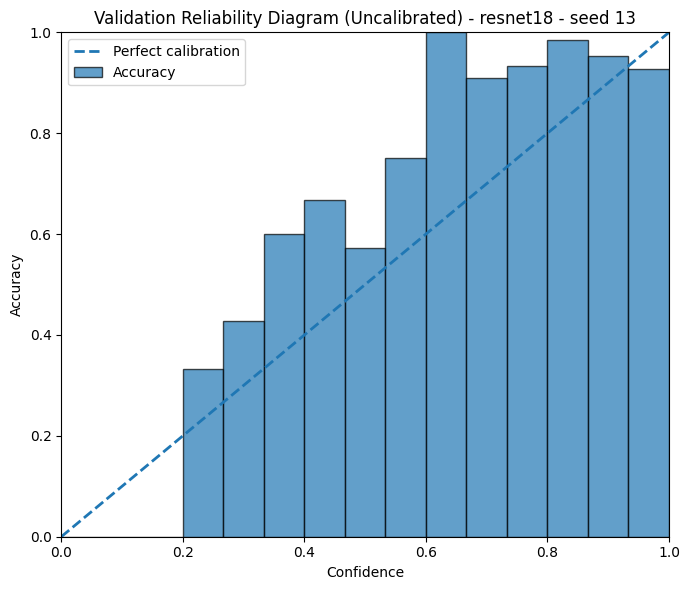

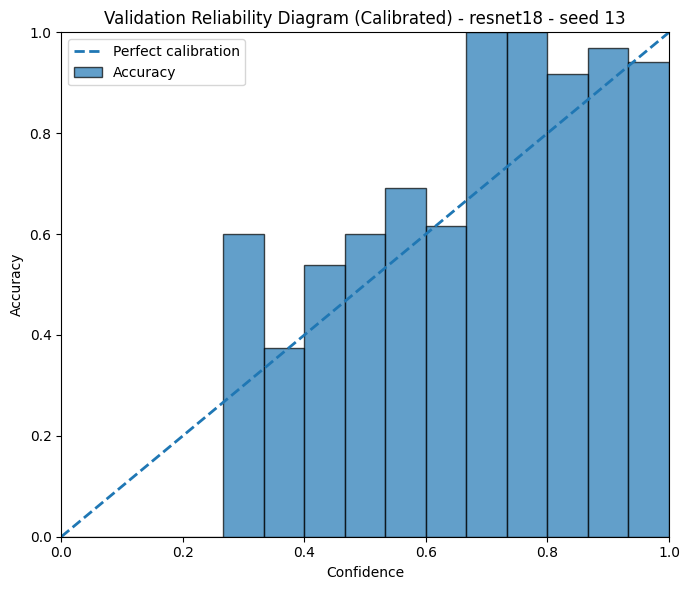

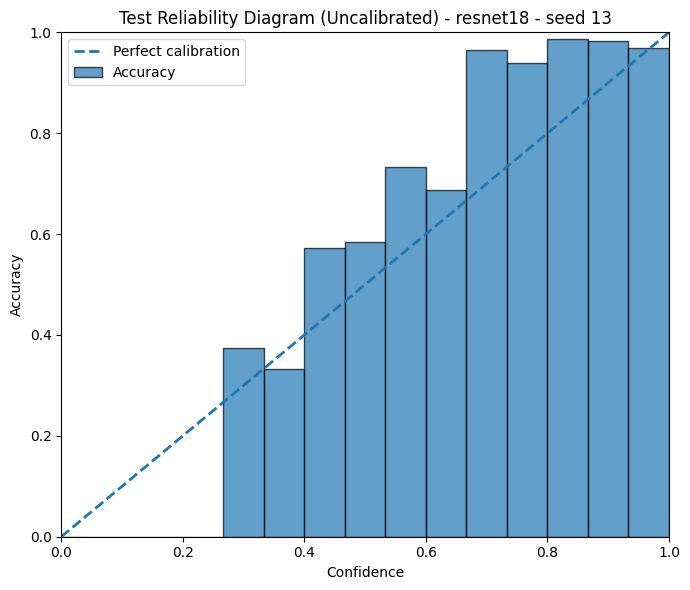

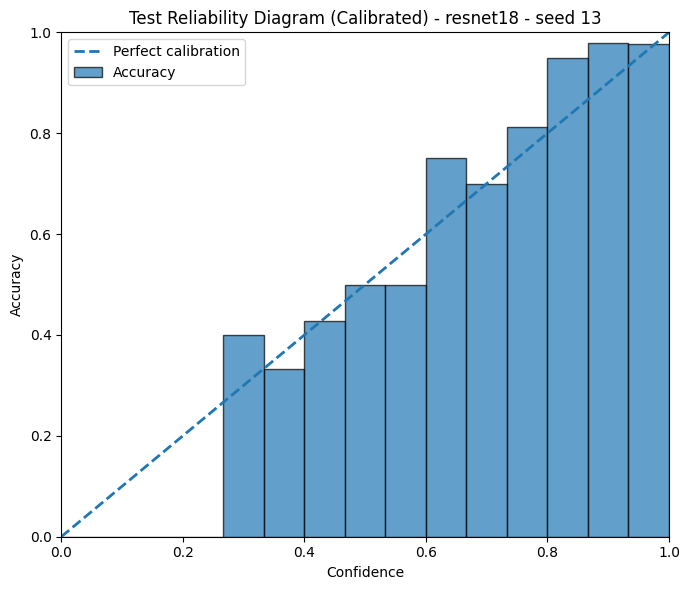


MODEL: resnet18
SEED : 13
TEMPERATURE: 0.812347

Validation metrics
split      setting  temperature      nll    brier      ece      mce
  val uncalibrated     1.000000 0.515476 0.205951 0.134386 0.364873
  val   calibrated     0.812347 0.468906 0.185498 0.075354 0.301785

Test metrics
split      setting  temperature      nll    brier      ece      mce
 test uncalibrated     1.000000 0.461772 0.182876 0.113922 0.261314
 test   calibrated     0.812347 0.410592 0.164785 0.049317 0.119331
Saved files:
- calibration_metrics.csv
- calibration_metrics.json
- temperature.json
- test_bins_calibrated.csv
- test_bins_uncalibrated.csv
- test_predictions_calibrated.csv
- test_reliability_calibrated.png
- test_reliability_uncalibrated.png
- val_bins_calibrated.csv
- val_bins_uncalibrated.csv
- val_predictions_calibrated.csv
- val_reliability_calibrated.png
- val_reliability_uncalibrated.png


In [21]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# ---------------- CONFIG ----------------
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 13                          # 42 first, then change to 13 or 87 later

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
N_BINS = 15

# ---------------- PATHS ----------------
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

SOURCE_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
TARGET_RUN_DIR = CALIBRATION_DIR / RUN_NAME
TARGET_RUN_DIR.mkdir(parents=True, exist_ok=True)

VAL_PRED_CSV = SOURCE_RUN_DIR / "val_predictions.csv"
TEST_PRED_CSV = SOURCE_RUN_DIR / "test_predictions.csv"

print("BASE_DIR       :", BASE_DIR)
print("PROJECT_ROOT   :", PROJECT_ROOT)
print("SOURCE_RUN_DIR :", SOURCE_RUN_DIR)
print("TARGET_RUN_DIR :", TARGET_RUN_DIR)
print("VAL_PRED_CSV   :", VAL_PRED_CSV, "->", VAL_PRED_CSV.exists())
print("TEST_PRED_CSV  :", TEST_PRED_CSV, "->", TEST_PRED_CSV.exists())
val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

print("val_df shape :", val_df.shape)
print("test_df shape:", test_df.shape)

display(val_df.head(2))
display(test_df.head(2))
logit_cols = [c for c in val_df.columns if c.startswith("logit_class_")]
prob_cols = [c for c in val_df.columns if c.startswith("prob_class_")]

if len(logit_cols) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} logit columns, found {len(logit_cols)}")

if len(prob_cols) != NUM_CLASSES:
    print("Warning: probability columns not found exactly as expected. Continuing with logits only.")

logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[-1]))
prob_cols = sorted(prob_cols, key=lambda x: int(x.split("_")[-1])) if len(prob_cols) == NUM_CLASSES else []

val_logits = val_df[logit_cols].values.astype(np.float32)
test_logits = test_df[logit_cols].values.astype(np.float32)

val_labels = val_df["y_true"].values.astype(np.int64)
test_labels = test_df["y_true"].values.astype(np.int64)

print("val_logits shape :", val_logits.shape)
print("test_logits shape:", test_logits.shape)
print("val_labels shape :", val_labels.shape)
print("test_labels shape:", test_labels.shape)
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def plot_reliability_diagram(bin_data, title, save_path=None):
    bin_centers = []
    bin_accs = []
    bin_confs = []
    widths = []

    for row in bin_data:
        center = (row["bin_lower"] + row["bin_upper"]) / 2.0
        width = row["bin_upper"] - row["bin_lower"]
        bin_centers.append(center)
        bin_accs.append(row["bin_acc"])
        bin_confs.append(row["bin_conf"])
        widths.append(width)

    plt.figure(figsize=(7, 6))
    plt.bar(bin_centers, bin_accs, width=widths, alpha=0.7, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
val_logits_t = torch.tensor(val_logits, dtype=torch.float32)
val_labels_t = torch.tensor(val_labels, dtype=torch.long)

log_temperature = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

optimizer = optim.LBFGS([log_temperature], lr=0.01, max_iter=100)

def closure():
    optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_logits = val_logits_t / temperature
    loss = nn.CrossEntropyLoss()(scaled_logits, val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)

best_temperature = float(torch.exp(log_temperature).item())

print("Learned temperature T:", best_temperature)
val_logits_cal = val_logits / best_temperature
test_logits_cal = test_logits / best_temperature

val_probs_uncal = softmax_numpy(val_logits)
test_probs_uncal = softmax_numpy(test_logits)

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

print("Validation and test calibrated probabilities computed.")
# ---------- Validation ----------
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)

val_brier_uncal = multiclass_brier_score(val_probs_uncal, val_labels, NUM_CLASSES)
val_brier_cal = multiclass_brier_score(val_probs_cal, val_labels, NUM_CLASSES)

val_ece_uncal, val_mce_uncal, val_bins_uncal = ece_mce_from_probs(val_probs_uncal, val_labels, n_bins=N_BINS)
val_ece_cal, val_mce_cal, val_bins_cal = ece_mce_from_probs(val_probs_cal, val_labels, n_bins=N_BINS)

# ---------- Test ----------
test_nll_uncal = nll_from_logits(test_logits, test_labels)
test_nll_cal = nll_from_logits(test_logits_cal, test_labels)

test_brier_uncal = multiclass_brier_score(test_probs_uncal, test_labels, NUM_CLASSES)
test_brier_cal = multiclass_brier_score(test_probs_cal, test_labels, NUM_CLASSES)

test_ece_uncal, test_mce_uncal, test_bins_uncal = ece_mce_from_probs(test_probs_uncal, test_labels, n_bins=N_BINS)
test_ece_cal, test_mce_cal, test_bins_cal = ece_mce_from_probs(test_probs_cal, test_labels, n_bins=N_BINS)

metrics_rows = [
    {
        "split": "val",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": val_nll_uncal,
        "brier": val_brier_uncal,
        "ece": val_ece_uncal,
        "mce": val_mce_uncal,
    },
    {
        "split": "val",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": val_nll_cal,
        "brier": val_brier_cal,
        "ece": val_ece_cal,
        "mce": val_mce_cal,
    },
    {
        "split": "test",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": test_nll_uncal,
        "brier": test_brier_uncal,
        "ece": test_ece_uncal,
        "mce": test_mce_uncal,
    },
    {
        "split": "test",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": test_nll_cal,
        "brier": test_brier_cal,
        "ece": test_ece_cal,
        "mce": test_mce_cal,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
metrics_csv = TARGET_RUN_DIR / "calibration_metrics.csv"
metrics_json = TARGET_RUN_DIR / "calibration_metrics.json"
temperature_json = TARGET_RUN_DIR / "temperature.json"

metrics_df.to_csv(metrics_csv, index=False)

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

with open(temperature_json, "w", encoding="utf-8") as f:
    json.dump({"temperature": best_temperature}, f, indent=2)

print("Saved:", metrics_csv)
print("Saved:", metrics_json)
print("Saved:", temperature_json)
val_cal_df = val_df.copy()
test_cal_df = test_df.copy()

for c in range(NUM_CLASSES):
    val_cal_df[f"cal_prob_class_{c}"] = val_probs_cal[:, c]
    val_cal_df[f"cal_logit_class_{c}"] = val_logits_cal[:, c]

    test_cal_df[f"cal_prob_class_{c}"] = test_probs_cal[:, c]
    test_cal_df[f"cal_logit_class_{c}"] = test_logits_cal[:, c]

val_cal_csv = TARGET_RUN_DIR / "val_predictions_calibrated.csv"
test_cal_csv = TARGET_RUN_DIR / "test_predictions_calibrated.csv"

val_cal_df.to_csv(val_cal_csv, index=False)
test_cal_df.to_csv(test_cal_csv, index=False)

print("Saved:", val_cal_csv)
print("Saved:", test_cal_csv)
val_bins_uncal_df = pd.DataFrame(val_bins_uncal)
val_bins_cal_df = pd.DataFrame(val_bins_cal)
test_bins_uncal_df = pd.DataFrame(test_bins_uncal)
test_bins_cal_df = pd.DataFrame(test_bins_cal)

val_bins_uncal_df.to_csv(TARGET_RUN_DIR / "val_bins_uncalibrated.csv", index=False)
val_bins_cal_df.to_csv(TARGET_RUN_DIR / "val_bins_calibrated.csv", index=False)
test_bins_uncal_df.to_csv(TARGET_RUN_DIR / "test_bins_uncalibrated.csv", index=False)
test_bins_cal_df.to_csv(TARGET_RUN_DIR / "test_bins_calibrated.csv", index=False)

print("Saved all bin tables.")
plot_reliability_diagram(
    val_bins_uncal,
    title=f"Validation Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    val_bins_cal,
    title=f"Validation Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_calibrated.png"
)
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)
print("\nMODEL:", MODEL_NAME)
print("SEED :", SEED)
print("TEMPERATURE:", round(best_temperature, 6))

print("\nValidation metrics")
print(metrics_df[metrics_df["split"] == "val"].to_string(index=False))

print("\nTest metrics")
print(metrics_df[metrics_df["split"] == "test"].to_string(index=False))
saved_files = sorted([p.name for p in TARGET_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)



Imports loaded successfully.
BASE_DIR       : /mnt/e/CVPR
PROJECT_ROOT   : /mnt/e/CVPR/steel_failure_aware
SOURCE_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
TARGET_RUN_DIR : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
VAL_PRED_CSV   : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/val_predictions.csv -> True
TEST_PRED_CSV  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/test_predictions.csv -> True
val_df shape : (347, 23)
test_df shape: (347, 23)


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/3/img_08_425008500_00873.jpg,2,2,0.004719,-0.620643,0.001172,-2.013404,0.931979,4.665031,0.001219,...,0.001066,-2.108181,0.009927,0.123017,0.021081,0.876111,0.016405,0.625336,0.002926,-1.098617
1,/mnt/e/CVPR/GC10/6/img_02_436152900_00563.jpg,5,5,0.009002,-1.412094,0.011325,-1.182526,0.011908,-1.132352,0.037071,...,0.756072,3.018592,0.013697,-0.992354,0.080462,0.778236,0.049668,0.295811,0.014266,-0.951631


,filepath,y_true,y_pred,prob_class_0,logit_class_0,prob_class_1,logit_class_1,prob_class_2,logit_class_2,prob_class_3,...,prob_class_5,logit_class_5,prob_class_6,logit_class_6,prob_class_7,logit_class_7,prob_class_8,logit_class_8,prob_class_9,logit_class_9
0,/mnt/e/CVPR/GC10/9/img_01_4402117100_00006.jpg,8,3,0.012762,-1.514026,0.011393,-1.627454,0.023091,-0.921021,0.340556,...,0.014493,-1.386830,0.131959,0.822016,0.150777,0.955326,0.145217,0.917752,0.053601,-0.078902
1,/mnt/e/CVPR/GC10/3/img_08_425503800_00053.jpg,2,2,0.002100,-1.208343,0.004949,-0.351251,0.947205,4.903158,0.002851,...,0.001137,-1.821787,0.003957,-0.574792,0.018639,0.974914,0.013521,0.653877,0.003731,-0.633716


val_logits shape : (347, 10)
test_logits shape: (347, 10)
val_labels shape : (347,)
test_labels shape: (347,)
Learned temperature T: 0.783771812915802
Validation and test calibrated probabilities computed.


,split,setting,temperature,nll,brier,ece,mce
0,val,uncalibrated,1.000000,0.451587,0.185558,0.136873,0.377698
1,val,calibrated,0.783772,0.387006,0.165088,0.058196,0.624836
2,test,uncalibrated,1.000000,0.527229,0.199619,0.131054,0.292002
3,test,calibrated,0.783772,0.483654,0.179542,0.059499,0.304309


Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/calibration_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/calibration_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/temperature.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/val_predictions_calibrated.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87/test_predictions_calibrated.csv
Saved all bin tables.


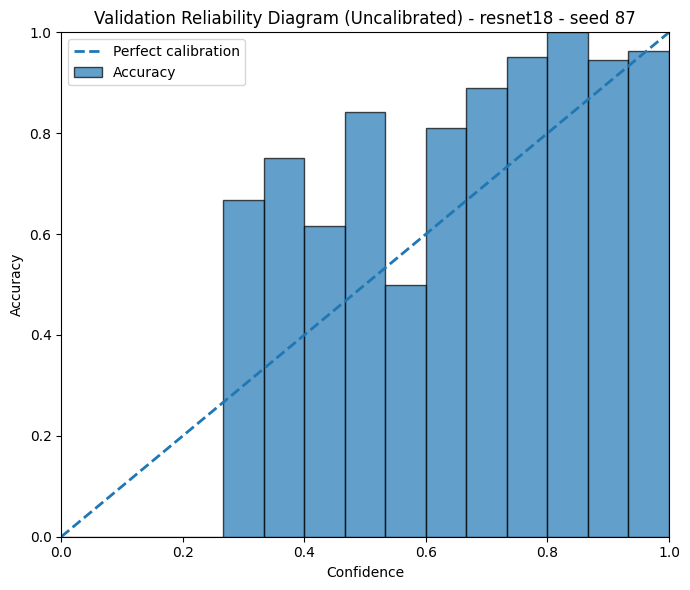

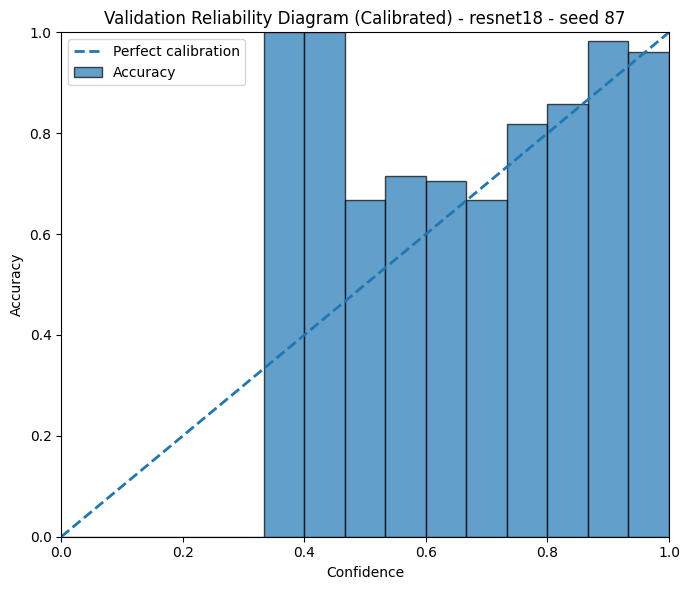

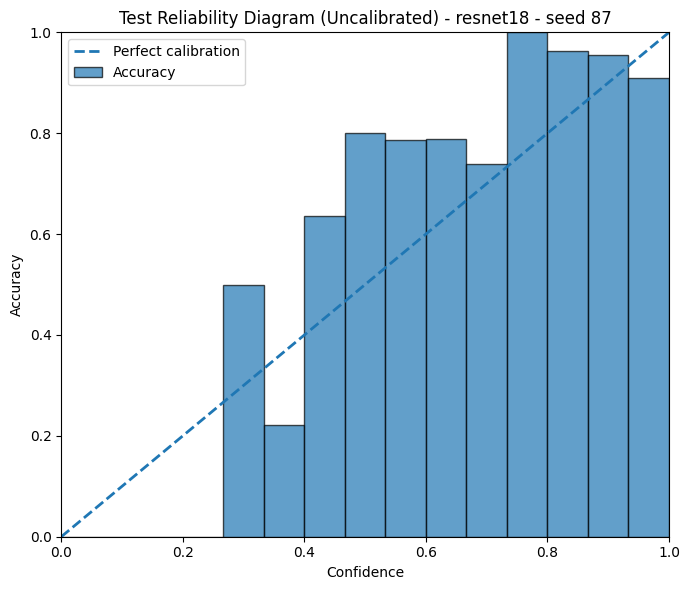

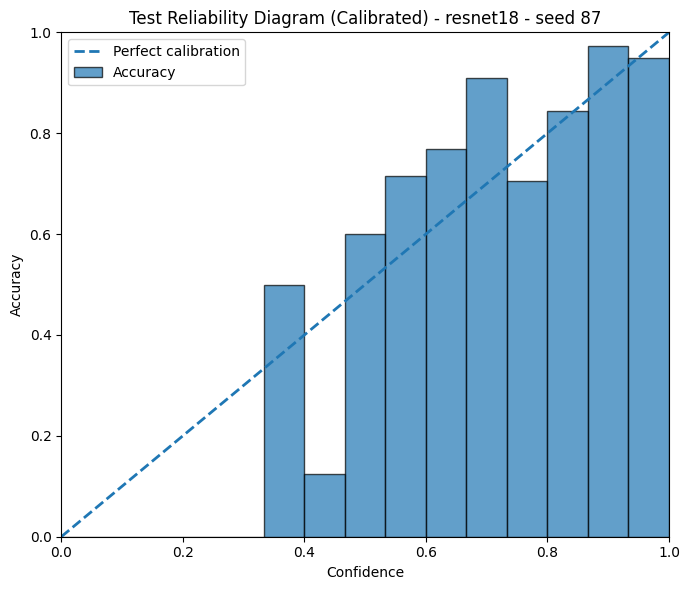


MODEL: resnet18
SEED : 87
TEMPERATURE: 0.783772

Validation metrics
split      setting  temperature      nll    brier      ece      mce
  val uncalibrated     1.000000 0.451587 0.185558 0.136873 0.377698
  val   calibrated     0.783772 0.387006 0.165088 0.058196 0.624836

Test metrics
split      setting  temperature      nll    brier      ece      mce
 test uncalibrated     1.000000 0.527229 0.199619 0.131054 0.292002
 test   calibrated     0.783772 0.483654 0.179542 0.059499 0.304309
Saved files:
- calibration_metrics.csv
- calibration_metrics.json
- temperature.json
- test_bins_calibrated.csv
- test_bins_uncalibrated.csv
- test_predictions_calibrated.csv
- test_reliability_calibrated.png
- test_reliability_uncalibrated.png
- val_bins_calibrated.csv
- val_bins_uncalibrated.csv
- val_predictions_calibrated.csv
- val_reliability_calibrated.png
- val_reliability_uncalibrated.png


In [22]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# ---------------- CONFIG ----------------
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 87                          # 42 first, then change to 13 or 87 later

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
N_BINS = 15

# ---------------- PATHS ----------------
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

SOURCE_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
TARGET_RUN_DIR = CALIBRATION_DIR / RUN_NAME
TARGET_RUN_DIR.mkdir(parents=True, exist_ok=True)

VAL_PRED_CSV = SOURCE_RUN_DIR / "val_predictions.csv"
TEST_PRED_CSV = SOURCE_RUN_DIR / "test_predictions.csv"

print("BASE_DIR       :", BASE_DIR)
print("PROJECT_ROOT   :", PROJECT_ROOT)
print("SOURCE_RUN_DIR :", SOURCE_RUN_DIR)
print("TARGET_RUN_DIR :", TARGET_RUN_DIR)
print("VAL_PRED_CSV   :", VAL_PRED_CSV, "->", VAL_PRED_CSV.exists())
print("TEST_PRED_CSV  :", TEST_PRED_CSV, "->", TEST_PRED_CSV.exists())
val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

print("val_df shape :", val_df.shape)
print("test_df shape:", test_df.shape)

display(val_df.head(2))
display(test_df.head(2))
logit_cols = [c for c in val_df.columns if c.startswith("logit_class_")]
prob_cols = [c for c in val_df.columns if c.startswith("prob_class_")]

if len(logit_cols) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} logit columns, found {len(logit_cols)}")

if len(prob_cols) != NUM_CLASSES:
    print("Warning: probability columns not found exactly as expected. Continuing with logits only.")

logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[-1]))
prob_cols = sorted(prob_cols, key=lambda x: int(x.split("_")[-1])) if len(prob_cols) == NUM_CLASSES else []

val_logits = val_df[logit_cols].values.astype(np.float32)
test_logits = test_df[logit_cols].values.astype(np.float32)

val_labels = val_df["y_true"].values.astype(np.int64)
test_labels = test_df["y_true"].values.astype(np.int64)

print("val_logits shape :", val_logits.shape)
print("test_logits shape:", test_logits.shape)
print("val_labels shape :", val_labels.shape)
print("test_labels shape:", test_labels.shape)
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def nll_from_logits(logits: np.ndarray, labels: np.ndarray) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    loss = nn.CrossEntropyLoss()(logits_t, labels_t)
    return float(loss.item())

def multiclass_brier_score(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def calibration_bins(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        if bin_upper == 1.0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_acc = np.mean(correctness[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            bin_count = int(np.sum(in_bin))
        else:
            bin_acc = 0.0
            bin_conf = 0.0
            bin_count = 0

        bin_data.append({
            "bin_lower": float(bin_lower),
            "bin_upper": float(bin_upper),
            "bin_acc": float(bin_acc),
            "bin_conf": float(bin_conf),
            "bin_count": int(bin_count),
            "bin_prop": float(prop_in_bin),
        })

    return bin_data

def ece_mce_from_probs(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    bin_data = calibration_bins(probs, labels, n_bins=n_bins)

    ece = 0.0
    mce = 0.0
    for row in bin_data:
        gap = abs(row["bin_acc"] - row["bin_conf"])
        ece += row["bin_prop"] * gap
        mce = max(mce, gap)

    return float(ece), float(mce), bin_data
def plot_reliability_diagram(bin_data, title, save_path=None):
    bin_centers = []
    bin_accs = []
    bin_confs = []
    widths = []

    for row in bin_data:
        center = (row["bin_lower"] + row["bin_upper"]) / 2.0
        width = row["bin_upper"] - row["bin_lower"]
        bin_centers.append(center)
        bin_accs.append(row["bin_acc"])
        bin_confs.append(row["bin_conf"])
        widths.append(width)

    plt.figure(figsize=(7, 6))
    plt.bar(bin_centers, bin_accs, width=widths, alpha=0.7, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
val_logits_t = torch.tensor(val_logits, dtype=torch.float32)
val_labels_t = torch.tensor(val_labels, dtype=torch.long)

log_temperature = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

optimizer = optim.LBFGS([log_temperature], lr=0.01, max_iter=100)

def closure():
    optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_logits = val_logits_t / temperature
    loss = nn.CrossEntropyLoss()(scaled_logits, val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)

best_temperature = float(torch.exp(log_temperature).item())

print("Learned temperature T:", best_temperature)
val_logits_cal = val_logits / best_temperature
test_logits_cal = test_logits / best_temperature

val_probs_uncal = softmax_numpy(val_logits)
test_probs_uncal = softmax_numpy(test_logits)

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

print("Validation and test calibrated probabilities computed.")
# ---------- Validation ----------
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)

val_brier_uncal = multiclass_brier_score(val_probs_uncal, val_labels, NUM_CLASSES)
val_brier_cal = multiclass_brier_score(val_probs_cal, val_labels, NUM_CLASSES)

val_ece_uncal, val_mce_uncal, val_bins_uncal = ece_mce_from_probs(val_probs_uncal, val_labels, n_bins=N_BINS)
val_ece_cal, val_mce_cal, val_bins_cal = ece_mce_from_probs(val_probs_cal, val_labels, n_bins=N_BINS)

# ---------- Test ----------
test_nll_uncal = nll_from_logits(test_logits, test_labels)
test_nll_cal = nll_from_logits(test_logits_cal, test_labels)

test_brier_uncal = multiclass_brier_score(test_probs_uncal, test_labels, NUM_CLASSES)
test_brier_cal = multiclass_brier_score(test_probs_cal, test_labels, NUM_CLASSES)

test_ece_uncal, test_mce_uncal, test_bins_uncal = ece_mce_from_probs(test_probs_uncal, test_labels, n_bins=N_BINS)
test_ece_cal, test_mce_cal, test_bins_cal = ece_mce_from_probs(test_probs_cal, test_labels, n_bins=N_BINS)

metrics_rows = [
    {
        "split": "val",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": val_nll_uncal,
        "brier": val_brier_uncal,
        "ece": val_ece_uncal,
        "mce": val_mce_uncal,
    },
    {
        "split": "val",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": val_nll_cal,
        "brier": val_brier_cal,
        "ece": val_ece_cal,
        "mce": val_mce_cal,
    },
    {
        "split": "test",
        "setting": "uncalibrated",
        "temperature": 1.0,
        "nll": test_nll_uncal,
        "brier": test_brier_uncal,
        "ece": test_ece_uncal,
        "mce": test_mce_uncal,
    },
    {
        "split": "test",
        "setting": "calibrated",
        "temperature": best_temperature,
        "nll": test_nll_cal,
        "brier": test_brier_cal,
        "ece": test_ece_cal,
        "mce": test_mce_cal,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
metrics_csv = TARGET_RUN_DIR / "calibration_metrics.csv"
metrics_json = TARGET_RUN_DIR / "calibration_metrics.json"
temperature_json = TARGET_RUN_DIR / "temperature.json"

metrics_df.to_csv(metrics_csv, index=False)

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(metrics_rows, f, indent=2)

with open(temperature_json, "w", encoding="utf-8") as f:
    json.dump({"temperature": best_temperature}, f, indent=2)

print("Saved:", metrics_csv)
print("Saved:", metrics_json)
print("Saved:", temperature_json)
val_cal_df = val_df.copy()
test_cal_df = test_df.copy()

for c in range(NUM_CLASSES):
    val_cal_df[f"cal_prob_class_{c}"] = val_probs_cal[:, c]
    val_cal_df[f"cal_logit_class_{c}"] = val_logits_cal[:, c]

    test_cal_df[f"cal_prob_class_{c}"] = test_probs_cal[:, c]
    test_cal_df[f"cal_logit_class_{c}"] = test_logits_cal[:, c]

val_cal_csv = TARGET_RUN_DIR / "val_predictions_calibrated.csv"
test_cal_csv = TARGET_RUN_DIR / "test_predictions_calibrated.csv"

val_cal_df.to_csv(val_cal_csv, index=False)
test_cal_df.to_csv(test_cal_csv, index=False)

print("Saved:", val_cal_csv)
print("Saved:", test_cal_csv)
val_bins_uncal_df = pd.DataFrame(val_bins_uncal)
val_bins_cal_df = pd.DataFrame(val_bins_cal)
test_bins_uncal_df = pd.DataFrame(test_bins_uncal)
test_bins_cal_df = pd.DataFrame(test_bins_cal)

val_bins_uncal_df.to_csv(TARGET_RUN_DIR / "val_bins_uncalibrated.csv", index=False)
val_bins_cal_df.to_csv(TARGET_RUN_DIR / "val_bins_calibrated.csv", index=False)
test_bins_uncal_df.to_csv(TARGET_RUN_DIR / "test_bins_uncalibrated.csv", index=False)
test_bins_cal_df.to_csv(TARGET_RUN_DIR / "test_bins_calibrated.csv", index=False)

print("Saved all bin tables.")
plot_reliability_diagram(
    val_bins_uncal,
    title=f"Validation Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    val_bins_cal,
    title=f"Validation Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "val_reliability_calibrated.png"
)
plot_reliability_diagram(
    test_bins_uncal,
    title=f"Test Reliability Diagram (Uncalibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_bins_cal,
    title=f"Test Reliability Diagram (Calibrated) - {MODEL_NAME} - seed {SEED}",
    save_path=TARGET_RUN_DIR / "test_reliability_calibrated.png"
)
print("\nMODEL:", MODEL_NAME)
print("SEED :", SEED)
print("TEMPERATURE:", round(best_temperature, 6))

print("\nValidation metrics")
print(metrics_df[metrics_df["split"] == "val"].to_string(index=False))

print("\nTest metrics")
print(metrics_df[metrics_df["split"] == "test"].to_string(index=False))
saved_files = sorted([p.name for p in TARGET_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)



In [23]:
from pathlib import Path
import json
import pandas as pd

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
SUMMARY_DIR = CALIBRATION_DIR / "summaries"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# RUNS TO COLLECT
# =========================
run_names = [
    "mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42",
    "mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13",
    "mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87",
    "resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42",
    "resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13",
    "resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87",
]

# =========================
# HELPER
# =========================
def parse_run_name(run_name: str):
    parts = run_name.split("__")
    model = parts[0]
    seed = int(parts[-1].split("_")[-1])
    return model, seed

summary_rows = []

for run_name in run_names:
    run_dir = CALIBRATION_DIR / run_name
    metrics_csv = run_dir / "calibration_metrics.csv"
    temp_json = run_dir / "temperature.json"

    if not metrics_csv.exists():
        print(f"Missing metrics file: {metrics_csv}")
        continue

    if not temp_json.exists():
        print(f"Missing temperature file: {temp_json}")
        continue

    metrics_df = pd.read_csv(metrics_csv)

    with open(temp_json, "r", encoding="utf-8") as f:
        temp_dict = json.load(f)

    temperature = float(temp_dict["temperature"])
    model, seed = parse_run_name(run_name)

    # extract rows
    val_uncal = metrics_df[(metrics_df["split"] == "val") & (metrics_df["setting"] == "uncalibrated")].iloc[0]
    val_cal   = metrics_df[(metrics_df["split"] == "val") & (metrics_df["setting"] == "calibrated")].iloc[0]
    test_uncal = metrics_df[(metrics_df["split"] == "test") & (metrics_df["setting"] == "uncalibrated")].iloc[0]
    test_cal   = metrics_df[(metrics_df["split"] == "test") & (metrics_df["setting"] == "calibrated")].iloc[0]

    summary_rows.append({
        "Model": model,
        "Seed": seed,
        "Temperature": temperature,

        "Val NLL uncal": float(val_uncal["nll"]),
        "Val NLL cal": float(val_cal["nll"]),
        "Val Brier uncal": float(val_uncal["brier"]),
        "Val Brier cal": float(val_cal["brier"]),
        "Val ECE uncal": float(val_uncal["ece"]),
        "Val ECE cal": float(val_cal["ece"]),
        "Val MCE uncal": float(val_uncal["mce"]),
        "Val MCE cal": float(val_cal["mce"]),

        "Test NLL uncal": float(test_uncal["nll"]),
        "Test NLL cal": float(test_cal["nll"]),
        "Test Brier uncal": float(test_uncal["brier"]),
        "Test Brier cal": float(test_cal["brier"]),
        "Test ECE uncal": float(test_uncal["ece"]),
        "Test ECE cal": float(test_cal["ece"]),
        "Test MCE uncal": float(test_uncal["mce"]),
        "Test MCE cal": float(test_cal["mce"]),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["Model", "Seed"]).reset_index(drop=True)

summary_csv = SUMMARY_DIR / "calibration_summary_table.csv"
summary_xlsx = SUMMARY_DIR / "calibration_summary_table.xlsx"

summary_df.to_csv(summary_csv, index=False)
summary_df.to_excel(summary_xlsx, index=False)

print("Saved:", summary_csv)
print("Saved:", summary_xlsx)
display(summary_df)

Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/summaries/calibration_summary_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/calibration/summaries/calibration_summary_table.xlsx


,Model,Seed,Temperature,Val NLL uncal,Val NLL cal,Val Brier uncal,Val Brier cal,Val ECE uncal,Val ECE cal,Val MCE uncal,Val MCE cal,Test NLL uncal,Test NLL cal,Test Brier uncal,Test Brier cal,Test ECE uncal,Test ECE cal,Test MCE uncal,Test MCE cal
0,mobilenetv3_small,13,0.854852,0.552178,0.524520,0.243456,0.234185,0.087534,0.074043,0.252104,0.232604,0.463741,0.424178,0.197616,0.186479,0.115854,0.058320,0.404556,0.371561
1,mobilenetv3_small,42,0.882529,0.617443,0.599231,0.282419,0.276886,0.078246,0.056828,0.808987,0.798703,0.558671,0.521033,0.243274,0.230820,0.116475,0.083966,0.261537,0.241654
2,mobilenetv3_small,87,0.823034,0.521429,0.480120,0.226076,0.211652,0.123952,0.074109,0.446019,0.303335,0.579798,0.546039,0.247845,0.233032,0.109546,0.064090,0.303683,0.144753
3,resnet18,13,0.812347,0.515476,0.468906,0.205951,0.185498,0.134386,0.075354,0.364873,0.301785,0.461772,0.410592,0.182876,0.164785,0.113922,0.049317,0.261314,0.119331
4,resnet18,42,0.882186,0.975303,0.957580,0.427665,0.417282,0.116639,0.085984,0.345204,0.271326,0.952841,0.933131,0.415198,0.403155,0.124220,0.092393,0.293341,0.260992
5,resnet18,87,0.783772,0.451587,0.387006,0.185558,0.165088,0.136873,0.058196,0.377698,0.624836,0.527229,0.483654,0.199619,0.179542,0.131054,0.059499,0.292002,0.304309
